# 강원도 산불 심화 EDA3: 발생원인 프록시 기반 날씨·공간 비교

이 노트북은 `발생원인명`이 전부 결측인 강원도 2020~2021년 산불 발생 데이터를 직접 원인 라벨로 분석하지 않는다.
대신 기존 전국 산불 원인 분포에서 입산자·등산객 등 야외활동 원인이 큰 축으로 나타난 점을 배경 가설로만 두고,
현재 강원도 분석 데이터에는 `등산로 또는 임도 500m 이내` 접근성 기준의 원인 프록시를 새로 만든다.

- `입산활동 발화 후보`: 등산로 또는 임도 최단거리 500m 이내
- `기타 인간활동 발화 후보`: 위 조건에 해당하지 않는 산불
- 이 라벨은 실제 원인이 아니라 접근성 기반 탐색 프록시이다.
- 기존 심화 EDA와 동일하게 기상셀 미매칭 산불 4건은 최근접 보정 없이 제외한다.
- 비발생 비교는 같은 기상셀·월·시간대 매칭 비발생 시점과, 등산로·임도 선형의 비발생 공간 샘플을 분리해서 해석한다.


## 0. 환경 설정과 공통 함수

`How_to_EDA.md` 기준에 맞춰 한글 폰트, 결측 감사, 효과크기, FDR 보정, 공간 최단거리, DEM 샘플링 함수를 먼저 정의한다.


In [10]:
from pathlib import Path
import gc
import math
import os
import time
import warnings

if os.environ.get("EDA3_SCRIPT_RUN") == "1":
    import matplotlib
    matplotlib.use("Agg")

import geopandas as gpd
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from rasterio.transform import rowcol
from scipy import stats
from shapely import wkt
from shapely.geometry import Point
from shapely.strtree import STRtree

warnings.filterwarnings("ignore")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print
    def Markdown(text):
        return text

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False,
    },
)
plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

ROOT = Path("D:/farm-system-public-02")
WEATHER_DIR = ROOT / "data" / "강원도_날씨데이터"
FIRE_DIR = ROOT / "data" / "강원도_데이터"
SPATIAL_DIR = FIRE_DIR / "강원도_공간데이터"
FIRE_SPATIAL_DIR = FIRE_DIR / "산불_공간데이터"

TYPE_ORDER = ["영동 해안형", "영서 내륙형", "고지·산간형"]
ADDR_ORDER = ["임야번지(산)", "일반번지"]
CAUSE_ORDER = ["입산활동 발화 후보", "기타 인간활동 발화 후보"]
CAUSE_PALETTE = {"입산활동 발화 후보": "#009E73", "기타 인간활동 발화 후보": "#4C72B0"}
TYPE_PALETTE = {"영동 해안형": "#D55E00", "영서 내륙형": "#0072B2", "고지·산간형": "#009E73"}
RANDOM_STATE = 20260604

SAVE_PLOT_IMAGES = os.environ.get("EDA3_SAVE_PLOTS") == "1"
PLOT_DIR = ROOT / "scratch" / "eda3_plot_check"
if SAVE_PLOT_IMAGES:
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(fig, name):
    if SAVE_PLOT_IMAGES:
        fig.savefig(PLOT_DIR / name, dpi=160, bbox_inches="tight")

def valid_summary(df, columns):
    rows = []
    for col in columns:
        exists = col in df.columns
        rows.append({
            "변수": col,
            "전체행": len(df),
            "유효표본수": int(df[col].notna().sum()) if exists else 0,
            "결측수": int(df[col].isna().sum()) if exists else len(df),
            "결측률_pct": round(float(df[col].isna().mean() * 100), 2) if exists else 100.0,
        })
    return pd.DataFrame(rows)

def cohen_d(a, b):
    a = pd.Series(a).dropna().astype(float)
    b = pd.Series(b).dropna().astype(float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    return np.nan if pooled == 0 else (a.mean() - b.mean()) / pooled

def bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    out = np.full(len(p), np.nan)
    valid = np.isfinite(p)
    pv = p[valid]
    if len(pv) == 0:
        return out
    order = np.argsort(pv)
    ranked = pv[order]
    adj = ranked * len(ranked) / np.arange(1, len(ranked) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    restored = np.empty_like(adj)
    restored[order] = np.clip(adj, 0, 1)
    out[valid] = restored
    return out

def mann_whitney_table(df, group_col, group_a, group_b, variables):
    rows = []
    a_df = df[df[group_col] == group_a]
    b_df = df[df[group_col] == group_b]
    for var in variables:
        if var not in df.columns:
            continue
        a = a_df[var].dropna()
        b = b_df[var].dropna()
        if len(a) < 3 or len(b) < 3:
            continue
        _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        rows.append({
            "변수": var,
            f"{group_a}_유효표본": len(a),
            f"{group_b}_유효표본": len(b),
            f"{group_a}_중앙값": a.median(),
            f"{group_b}_중앙값": b.median(),
            f"{group_a}_평균": a.mean(),
            f"{group_b}_평균": b.mean(),
            "Cohen_d": cohen_d(a, b),
            "p_value": p,
        })
    out = pd.DataFrame(rows)
    if not out.empty:
        out["FDR"] = bh_fdr(out["p_value"])
    return out

def paired_dz(diff):
    diff = pd.Series(diff).dropna().astype(float)
    if len(diff) < 2 or diff.std(ddof=1) == 0:
        return np.nan
    return diff.mean() / diff.std(ddof=1)

def cramer_v_table(df, row_col, col_col):
    table = pd.crosstab(df[row_col], df[col_col])
    table = table.loc[table.sum(axis=1) > 0, table.sum(axis=0) > 0]
    if table.shape[0] < 2 or table.shape[1] < 2:
        return table, {"chi2": np.nan, "p_value": np.nan, "dof": np.nan, "cramers_v": np.nan}
    chi2, p, dof, _ = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    v = np.sqrt((chi2 / n) / max(1, min(table.shape[0] - 1, table.shape[1] - 1)))
    return table, {"chi2": chi2, "p_value": p, "dof": dof, "cramers_v": v}

def row_pct(table):
    return table.div(table.sum(axis=1).replace(0, np.nan), axis=0).mul(100)

def angle_diff(a, b):
    return np.abs(((a - b + 180) % 360) - 180)

def build_spatial_index(geoms):
    geom_arr = np.asarray(pd.Series(geoms).dropna().values, dtype=object)
    return geom_arr, STRtree(geom_arr)

def nearest_distance_from_index(points_gdf, geom_arr, tree, label):
    if len(geom_arr) == 0:
        return [np.nan] * len(points_gdf)
    out = []
    for pt in np.asarray(points_gdf.geometry.values, dtype=object):
        nearest = tree.nearest(pt)
        geom = geom_arr[int(nearest)] if isinstance(nearest, (int, np.integer)) else nearest
        out.append(pt.distance(geom))
    print(f"- {label} 최단거리 완료")
    return out

def sample_array_at_points(points_gdf, arr, transform):
    coords = [(geom.x, geom.y) for geom in points_gdf.geometry]
    rows_cols = [rowcol(transform, x, y) for x, y in coords]
    vals = []
    h, w = arr.shape
    for r, c in rows_cols:
        if 0 <= r < h and 0 <= c < w:
            vals.append(arr[r, c])
        else:
            vals.append(np.nan)
    return vals

def sample_line_points(line_gdf, source_line, step_m=500):
    rows = []
    for idx, geom in enumerate(line_gdf.geometry):
        if geom is None or geom.is_empty:
            continue
        length = float(geom.length)
        if not np.isfinite(length) or length <= 0:
            continue
        distances = list(np.arange(0, length, step_m))
        if not distances or not math.isclose(distances[-1], length):
            distances.append(length)
        for j, dist in enumerate(distances):
            rows.append({
                "line_source_id": idx,
                "sample_id": f"{source_line}_{idx}_{j}",
                "source_line": source_line,
                "line_distance_m": dist,
                "geometry": geom.interpolate(dist),
            })
    return gpd.GeoDataFrame(rows, geometry="geometry", crs=line_gdf.crs)

def add_rolling_weather(hourly):
    hourly = hourly.sort_values(["기상셀ID", "일시"]).reset_index(drop=True)
    shifted = hourly.groupby("기상셀ID", sort=False)[["풍속_m_s", "습도_pct", "강수량_mm"]].shift(1)
    grouped = shifted.groupby(hourly["기상셀ID"], sort=False)
    for window in [24, 48, 72]:
        hourly[f"직전{window}h_평균풍속"] = grouped["풍속_m_s"].rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
        hourly[f"직전{window}h_최소습도"] = grouped["습도_pct"].rolling(window, min_periods=1).min().reset_index(level=0, drop=True)
        hourly[f"직전{window}h_강수량합"] = grouped["강수량_mm"].rolling(window, min_periods=1).sum().reset_index(level=0, drop=True)
    return hourly

print("현재 matplotlib font.family:", plt.rcParams["font.family"])
print("ROOT:", ROOT)


현재 matplotlib font.family: ['Malgun Gothic']
ROOT: D:\farm-system-public-02


## 1. 산불·날씨·지형·토지피복·접근성 기본 테이블

기존 심화 EDA와 같은 방식으로 산불 좌표를 기상셀에 결합하고, 발생시각·직전 24/48/72시간·D-1~D-3 날씨를 생성한다.
이후 산불 발생점에 지형, 토지피복, 도로·임도·등산로·생활권 접근성 변수를 붙인다.


In [11]:
t0 = time.time()
fire = pd.read_csv(FIRE_DIR / "강원도_산불발생.csv", encoding="utf-8-sig")
grid = gpd.read_file(WEATHER_DIR / "강원도날씨_격자.geojson").to_crs("EPSG:4326")
climate_type = pd.read_csv(WEATHER_DIR / "강원도날씨_기후지형유형_셀분류.csv", encoding="utf-8-sig")
topo = pd.read_csv(FIRE_SPATIAL_DIR / "강원도_산불_지형특성계산.csv", encoding="utf-8-sig")

fire["발생일시"] = pd.to_datetime(
    dict(year=fire["연도"], month=fire["월"], day=fire["일"]),
    errors="coerce",
) + pd.to_timedelta(fire["시간"].fillna(0).astype(int), unit="h")
fire["날짜"] = fire["발생일시"].dt.floor("D")
fire["월_key"] = fire["발생일시"].dt.month
fire["시간_key"] = fire["발생일시"].dt.hour
fire["addr_type"] = np.where(
    fire["발생지역번지"].fillna("").astype(str).str.strip().str.startswith("산"),
    "임야번지(산)",
    "일반번지",
)
fire["발생시간대구분"] = pd.cut(
    fire["시간_key"],
    bins=[-0.1, 5, 9, 13, 17, 23],
    labels=["야간(0~5시)", "아침(6~9시)", "한낮(10~13시)", "오후(14~17시)", "저녁(18~23시)"],
)

fire_gdf = gpd.GeoDataFrame(
    fire,
    geometry=gpd.points_from_xy(fire["경도"], fire["위도"]),
    crs="EPSG:4326",
)
fire_cells = gpd.sjoin(
    fire_gdf,
    grid[["기상셀ID", "기후권역", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"])
unmatched_ids = fire_cells.loc[fire_cells["기상셀ID"].isna(), "fire_id"].tolist()
fire_cells = fire_cells[fire_cells["기상셀ID"].notna()].drop(columns=["geometry"]).copy()
fire_cells = fire_cells.merge(climate_type[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left")
fire_core = fire_cells.merge(topo.drop(columns=["위도", "경도"]), on="fire_id", how="left")
fire_core.loc[fire_core["TWI(지형다습지수)"] > 1e8, "TWI(지형다습지수)"] = np.nan
fire_core["사면방향_deg"] = (np.degrees(np.arctan2(fire_core["사면방향_sin"], fire_core["사면방향_cos"])) + 360) % 360
del topo, fire_gdf, fire_cells
gc.collect()

land = gpd.read_file(
    SPATIAL_DIR / "강원도_토지피복도_세분류_병합_1m.gpkg",
    engine="pyogrio",
    columns=["L1_NAME", "L2_NAME"],
)
land["L1_NAME"] = land["L1_NAME"].fillna("미분류")
land["L2_NAME"] = land["L2_NAME"].fillna("미분류")
fire_points = gpd.GeoDataFrame(
    fire_core,
    geometry=gpd.points_from_xy(fire_core["경도"], fire_core["위도"]),
    crs="EPSG:4326",
).to_crs(land.crs)
fire_lc = gpd.sjoin(
    fire_points,
    land[["L1_NAME", "L2_NAME", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"])
fire_lc = fire_lc.drop_duplicates(subset="fire_id").reset_index(drop=True)
fire_lc["L1_NAME"] = fire_lc["L1_NAME"].fillna("미분류")
fire_lc["L2_NAME"] = fire_lc["L2_NAME"].fillna("미분류")
del fire_core, fire_points
gc.collect()

road = gpd.read_file(SPATIAL_DIR / "강원도_병합_도로.gpkg", engine="pyogrio", columns=[]).to_crs(land.crs)
trail_df = pd.read_csv(SPATIAL_DIR / "강원도_등산로.csv", encoding="utf-8-sig")
trail = gpd.GeoDataFrame(trail_df, geometry=trail_df["공간좌표"].apply(wkt.loads), crs="EPSG:4326").to_crs(land.crs)
imdo_df = pd.read_csv(SPATIAL_DIR / "강원도_임도망도.csv", encoding="utf-8-sig")
imdo = gpd.GeoDataFrame(imdo_df, geometry=imdo_df["공간좌표"].apply(wkt.loads), crs="EPSG:4326").to_crs(land.crs)

target_indices = {
    "도로": build_spatial_index(road.geometry),
    "임도": build_spatial_index(imdo.geometry),
    "등산로": build_spatial_index(trail.geometry),
    "산림지역": build_spatial_index(land.loc[land["L1_NAME"].eq("산림지역"), "geometry"]),
    "시가화건조지역": build_spatial_index(land.loc[land["L1_NAME"].eq("시가화건조지역"), "geometry"]),
    "농업지역": build_spatial_index(land.loc[land["L1_NAME"].eq("농업지역"), "geometry"]),
}
del road
gc.collect()
distance_specs = [
    ("도로", "도로_최단거리_m"),
    ("임도", "임도_최단거리_m"),
    ("등산로", "등산로_최단거리_m"),
    ("산림지역", "산림_최단거리_m"),
    ("시가화건조지역", "시가화_최단거리_m"),
    ("농업지역", "농업_최단거리_m"),
]
for label, col in distance_specs:
    geom_arr, tree = target_indices[label]
    fire_lc[col] = nearest_distance_from_index(fire_lc, geom_arr, tree, label)

fire_lc["생활권프록시"] = np.where(
    (fire_lc["도로_최단거리_m"] <= 30) | (fire_lc["시가화_최단거리_m"] <= 100) | (fire_lc["농업_최단거리_m"] <= 100),
    "도로/시가화/농업 인접",
    "비인접",
)

daily = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_일단위.csv", encoding="utf-8-sig")
hourly = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_시간단위.csv", encoding="utf-8-sig")
daily["날짜"] = pd.to_datetime(daily["날짜"])
hourly["일시"] = pd.to_datetime(hourly["일시"])
hourly["날짜"] = hourly["일시"].dt.floor("D")
hourly["월_key"] = hourly["일시"].dt.month.astype("int8")
hourly["시간_key"] = hourly["일시"].dt.hour.astype("int8")
hourly = add_rolling_weather(hourly)

hourly_day = (
    hourly.groupby(["기상셀ID", "날짜"], as_index=False)
    .agg(
        최소습도_pct=("습도_pct", "min"),
        강수량합_mm=("강수량_mm", "sum"),
    )
)
hourly_features = hourly[[
    "기상셀ID", "일시", "날짜", "월_key", "시간_key",
    "풍속_m_s", "강수량_mm", "습도_pct",
    "직전24h_평균풍속", "직전24h_최소습도", "직전24h_강수량합",
    "직전48h_평균풍속", "직전48h_최소습도", "직전48h_강수량합",
    "직전72h_평균풍속", "직전72h_최소습도", "직전72h_강수량합",
]].copy()
hourly_features = hourly_features.rename(columns={
    "풍속_m_s": "시점_풍속_m_s",
    "강수량_mm": "시점_강수량_mm",
    "습도_pct": "시점_습도_pct",
})
daily_features = daily.rename(columns={"최대순간풍속_m_s": "당일_최대순간풍속_m_s"})
hourly_features = hourly_features.merge(
    daily_features[["기상셀ID", "날짜", "당일_최대순간풍속_m_s"]],
    on=["기상셀ID", "날짜"],
    how="left",
)
for lag in [1, 2, 3]:
    lag_df = hourly_day.copy()
    lag_df["날짜"] = lag_df["날짜"] + pd.Timedelta(days=lag)
    lag_df = lag_df.rename(columns={
        "최소습도_pct": f"D-{lag}_최소습도_pct",
        "강수량합_mm": f"D-{lag}_강수량합_mm",
    })
    hourly_features = hourly_features.merge(lag_df, on=["기상셀ID", "날짜"], how="left")

float_cols = hourly_features.select_dtypes(include=["float64"]).columns
hourly_features[float_cols] = hourly_features[float_cols].astype("float32")
fire_lc = fire_lc.merge(
    hourly_features.rename(columns={"일시": "발생일시"}),
    on=["기상셀ID", "발생일시"],
    how="left",
    suffixes=("", "_weather"),
)
del daily, hourly, hourly_day, daily_features
gc.collect()

t1 = time.time()
print(f"기본 테이블 구성 완료: {t1 - t0:.1f}초")
print(f"- 산불 원자료: {len(fire):,}건")
print(f"- 기상셀 매칭 후 분석 산불: {len(fire_lc):,}건")
print(f"- 미매칭 제외 fire_id: {unmatched_ids}")
display(valid_summary(
    fire_lc,
    [
        "발생원인명", "시점_습도_pct", "시점_풍속_m_s", "직전24h_최소습도", "직전48h_최소습도", "직전72h_최소습도",
        "D-1_최소습도_pct", "D-2_최소습도_pct", "D-3_최소습도_pct",
        "고도(m)", "경사도(도)", "TPI(지형위치지수)", "TWI(지형다습지수)", "도로_최단거리_m", "임도_최단거리_m", "등산로_최단거리_m",
    ],
))


- 도로 최단거리 완료
- 임도 최단거리 완료
- 등산로 최단거리 완료
- 산림지역 최단거리 완료
- 시가화건조지역 최단거리 완료
- 농업지역 최단거리 완료
기본 테이블 구성 완료: 80.6초
- 산불 원자료: 3,405건
- 기상셀 매칭 후 분석 산불: 3,401건
- 미매칭 제외 fire_id: ['F_006690', 'F_009678', 'F_010665', 'F_010893']


,변수,전체행,유효표본수,결측수,결측률_pct
0,발생원인명,3401,0,3401,100.00
1,시점_습도_pct,3401,3401,0,0.00
2,시점_풍속_m_s,3401,3401,0,0.00
3,직전24h_최소습도,3401,3401,0,0.00
4,직전48h_최소습도,3401,3401,0,0.00
5,직전72h_최소습도,3401,3401,0,0.00
6,D-1_최소습도_pct,3401,3399,2,0.06
7,D-2_최소습도_pct,3401,3399,2,0.06
8,D-3_최소습도_pct,3401,3395,6,0.18
9,고도(m),3401,3401,0,0.00


## 2. 원인 프록시 생성과 민감도 감사

500m 기준을 주 분석 라벨로 사용하고, 250m·1000m 기준을 민감도 라벨로 함께 만든다.
이 단계의 핵심은 표본 수와 층화 가능성을 먼저 확인하는 것이다.


### 500m 기준 원인 프록시 분포

,원인프록시_500m,건수,비율_pct
0,입산활동 발화 후보,1040,30.58
1,기타 인간활동 발화 후보,2361,69.42


### 거리 기준 민감도

,기준거리_m,입산활동_후보_건수,기타인간활동_후보_건수,입산활동_후보_비율_pct,500m라벨_일치율_pct
0,250,666,2735,19.58,89.00
1,500,1040,2361,30.58,100.00
2,1000,1760,1641,51.75,78.83


### 기후지형유형 x 원인프록시_500m

...

원인프록시_500m,입산활동 발화 후보,기타 인간활동 발화 후보
L1_NAME,,
나지,108,99
농업지역,80,207
미분류,41,306
산림지역,155,291
수역,5,10
습지,17,50
시가화건조지역,474,922
초지,160,476


원인프록시_500m,입산활동 발화 후보,기타 인간활동 발화 후보
L1_NAME,,
나지,52.17,47.83
농업지역,27.87,72.13
미분류,11.82,88.18
산림지역,34.75,65.25
수역,33.33,66.67
습지,25.37,74.63
시가화건조지역,33.95,66.05
초지,25.16,74.84


### 발생시간대구분 x 원인프록시_500m

원인프록시_500m,입산활동 발화 후보,기타 인간활동 발화 후보
발생시간대구분,,
야간(0~5시),10,19
아침(6~9시),167,187
한낮(10~13시),501,1360
오후(14~17시),301,660
저녁(18~23시),61,135


원인프록시_500m,입산활동 발화 후보,기타 인간활동 발화 후보
발생시간대구분,,
야간(0~5시),34.48,65.52
아침(6~9시),47.18,52.82
한낮(10~13시),26.92,73.08
오후(14~17시),31.32,68.68
저녁(18~23시),31.12,68.88


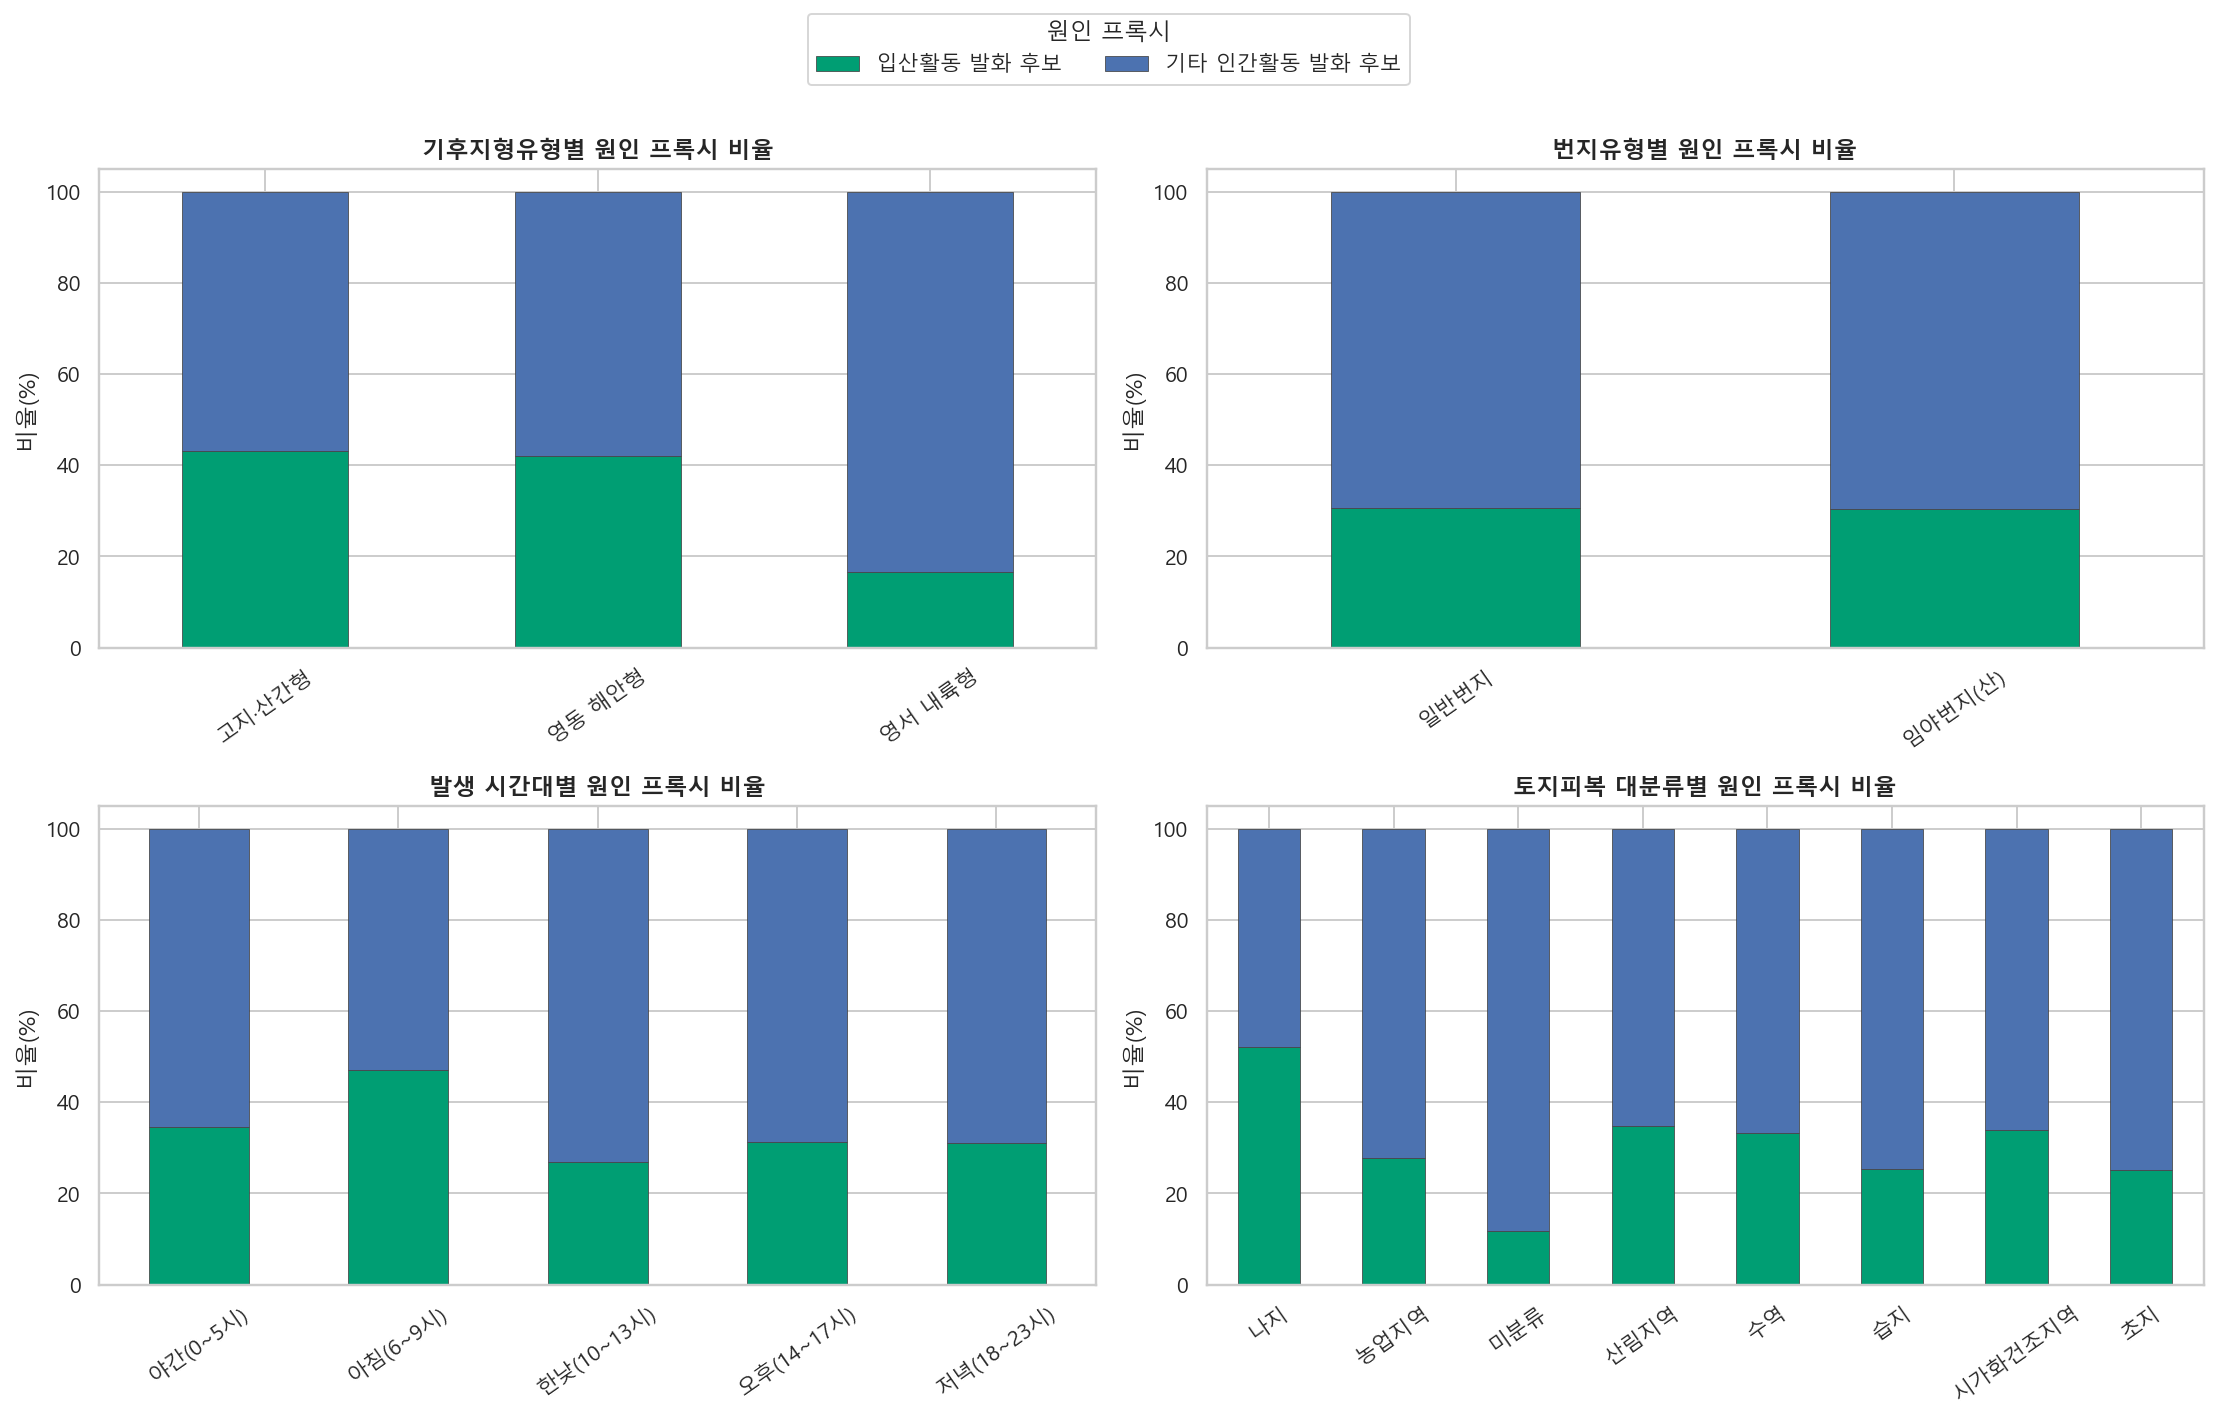

In [12]:
def make_cause_proxy(df, threshold_m):
    near_entry = (df["등산로_최단거리_m"] <= threshold_m) | (df["임도_최단거리_m"] <= threshold_m)
    return np.where(near_entry, "입산활동 발화 후보", "기타 인간활동 발화 후보")

for threshold in [250, 500, 1000]:
    fire_lc[f"원인프록시_{threshold}m"] = make_cause_proxy(fire_lc, threshold)

proxy_counts = (
    fire_lc["원인프록시_500m"].value_counts()
    .reindex(CAUSE_ORDER)
    .rename_axis("원인프록시_500m")
    .reset_index(name="건수")
)
proxy_counts["비율_pct"] = proxy_counts["건수"] / proxy_counts["건수"].sum() * 100

sensitivity_rows = []
for threshold in [250, 500, 1000]:
    counts = fire_lc[f"원인프록시_{threshold}m"].value_counts().reindex(CAUSE_ORDER, fill_value=0)
    sensitivity_rows.append({
        "기준거리_m": threshold,
        "입산활동_후보_건수": int(counts["입산활동 발화 후보"]),
        "기타인간활동_후보_건수": int(counts["기타 인간활동 발화 후보"]),
        "입산활동_후보_비율_pct": counts["입산활동 발화 후보"] / counts.sum() * 100,
        "500m라벨_일치율_pct": (fire_lc[f"원인프록시_{threshold}m"].eq(fire_lc["원인프록시_500m"]).mean() * 100),
    })
sensitivity = pd.DataFrame(sensitivity_rows)

display(Markdown("### 500m 기준 원인 프록시 분포"))
display(proxy_counts.round(2))
display(Markdown("### 거리 기준 민감도"))
display(sensitivity.round(2))

axis_tables = {}
for axis in ["기후지형유형", "addr_type", "L1_NAME", "발생시간대구분"]:
    ct = pd.crosstab(fire_lc[axis], fire_lc["원인프록시_500m"]).reindex(columns=CAUSE_ORDER)
    axis_tables[axis] = ct
    display(Markdown(f"### {axis} x 원인프록시_500m"))
    display(ct)
    display(row_pct(ct).round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=140)
plot_specs = [
    ("기후지형유형", "기후지형유형별 원인 프록시 비율"),
    ("addr_type", "번지유형별 원인 프록시 비율"),
    ("발생시간대구분", "발생 시간대별 원인 프록시 비율"),
    ("L1_NAME", "토지피복 대분류별 원인 프록시 비율"),
]
for ax, (axis, title) in zip(axes.ravel(), plot_specs):
    pct = row_pct(axis_tables[axis]).fillna(0)
    pct.plot(kind="bar", stacked=True, color=[CAUSE_PALETTE[c] for c in CAUSE_ORDER], ax=ax, edgecolor="#444444", linewidth=0.4)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("비율(%)")
    ax.tick_params(axis="x", rotation=35)
handles, labels = axes.ravel()[0].get_legend_handles_labels()
for ax in axes.ravel():
    if ax.get_legend() is not None:
        ax.get_legend().remove()
fig.legend(handles, labels, title="원인 프록시", loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.94])
save_plot(fig, "01_proxy_distribution.png")
plt.show()


> 기록 부재 극복을 위한 공간 프록시 도입: 강원도 최근 산불 데이터는 원인 기록이 전부 누락되어 있어, 기존 방식으로는 원인 분석이 불가능합니다. 이를 극복하기 위해 등산객이나 행락객 등의 활동이 빈번한 '등산로'와 '임도' 주변 반경(500m)을 **입산활동 영향권(프록시)**으로 정의하여 우회적인 분석 틀을 마련했습니다.
> 임계치 검증: 설정한 반경(500m)이 분석 모델의 신뢰성을 담보할 수 있을 만큼 충분한 표본을 확보하면서도 공간적 구별력을 유지하는지 민감도를 사전 감사한 것입니다.

1. 기후지형에 따른 입산 산불 취약성 격차
   - 해석: 태백산맥 중심의 고지·산간형과 영동 해안형에서는 등산로와 임도 주변에서 발생하는 산불의 비중이 매우 높게 나타납니다. 반면, 평지가 많고 주거·상업 활동이 혼재된 영서 내륙형은 이 비율이 급격히 낮아집니다.
   - 의미: 영동 지역이나 험준한 산악 지형은 숲이 깊고 지형이 가파르기 때문에, 인간이 산속으로 진입하는 경로가 사실상 등산로나 임도로 강제됩니다. 따라서 이 지역의 산불 관리와 예방 순찰은 철저히 등산로 초입과 임도망 주변에 집중되어야 함을 뜻합니다. 반면 영서 내륙은 굳이 등산로가 아니더라도 주거지나 농경지 경계 등 다양한 지점을 통해 인간 활동으로 인한 산불이 발생할 가능성이 훨씬 높습니다.
2. 행정 지번 정보(주소)의 한계와 공간 정보의 필요성
   - 해석: 산불이 발생한 행정 주소지에 '산' 번지가 붙어 있는 임야 산불과 일반 지번 산불을 비교했을 때, 등산로나 임도 인접 비율은 사실상 차이가 전혀 없었습니다.
   - 의미: 주소지에 '산' 번지가 들어가 있더라도 실제로는 도로나 농경지에 딱 붙어 있는 경우가 많고, 반대로 일반 번지여도 깊은 등산로 초입에 인접해 있을 수 있습니다. 따라서 행정 주소상의 번지 구분만으로 '입산자 실화'와 '기타 생활 실화'를 구분하려는 기존의 관행적 접근은 왜곡된 결과를 낳을 수 있으며, 반드시 GIS 좌표를 기반으로 한 물리적 거리 분석을 수행해야만 실질적인 산불 원인 예측이 가능함을 보여줍니다.
3. 시간대별 인간 활동의 전형적인 라이프사이클 반영
   - 해석: 하루 중 **이른 아침(6시 ~ 9시)**에 발생하는 산불은 등산로 및 임도에 인접한 비중이 가장 높게 치솟습니다. 반면, **한낮(10시 ~ 13시)**에는 이 비율이 가장 낮게 내려앉습니다.
   - 의미: 이른 아침 시간대에는 일반적인 야외 활동이나 농가 소각 작업이 시작되기 전이므로, 아침 일찍 산을 찾는 등산객이나 산림 관리 작업자 등의 이동 경로 주변에서 불씨가 시작될 확률이 상대적으로 매우 큽니다. 반대로 한낮 시간대에는 등산로뿐만 아니라 농경지 소각, 생활 쓰레기 처리, 성묘객 성묘 등 주거지와 농경지 인근에서의 광범위한 인간 활동이 급증하면서 상대적으로 등산로 주변의 산불 비율이 묻히는(희석되는) 현상이 발생합니다.
4. 토지 환경과의 물리적 정합성
   - 해석: 토지피복상 맨땅(나지)이나 산림지역에서 등산로/임도 인접 비율이 높게 나타납니다.
   - 의미: 등산로나 임도는 숲을 개간하고 관통하여 만들어지는 선형 구조물이므로, 인접 지역이 자연스럽게 나무가 없는 훼손지(나지)나 산림 내부가 될 수밖에 없는 물리적 환경이 데이터상에 그대로 투영되어 신뢰성을 뒷받침합니다.

이 분석 영역은 **"어디서, 언제 일어난 산불이 입산자 활동과 밀접할 가능성이 높은가?"**에 대답을 줍니다. 종합하면 영동 해안 및 고지대 산악 지역에서, 그리고 이른 아침 시간대에 발생하는 산불일수록 등산객이나 산림 이동 차량 등의 입산 활동권 내에서 발화했을 가능성이 구조적으로 매우 높습니다.  
따라서 가을·봄철 건조기 순찰 노선을 짤 때 지리적으로는 영동/산간의 임도·등산로, 시간적으로는 이른 아침을 핵심 타깃으로 설정하는 것이 효율적이라는 의사결정적 인사이트를 제공합니다.

## 3. 발생점 내부 비교: 원인 프록시별 날씨·공간지표

산불 발생점만 놓고 `입산활동 발화 후보`와 `기타 인간활동 발화 후보`의 발생 당시 날씨, 선행 날씨, 지형, 접근성 차이를 비교한다.
이 비교는 실제 원인 검정이 아니라 접근성 라벨에 따른 환경 차이 검정이다.


### 원인 프록시별 날씨 변수 비교

,변수,입산활동 발화 후보_유효표본,기타 인간활동 발화 후보_유효표본,입산활동 발화 후보_중앙값,기타 인간활동 발화 후보_중앙값,입산활동 발화 후보_평균,기타 인간활동 발화 후보_평균,Cohen_d,p_value,FDR
7,직전48h_평균풍속,1040,2361,2.138400,1.943300,2.232100,2.003300,0.2271,0.0000,0.0000
6,직전24h_평균풍속,1040,2361,2.082100,1.805000,2.287400,2.046900,0.2126,0.0000,0.0000
8,직전72h_평균풍속,1040,2361,2.058800,1.846700,2.165500,1.982800,0.1931,0.0000,0.0000
14,D-3_최소습도_pct,1038,2357,38.029999,32.230000,40.822102,36.703300,0.2426,0.0000,0.0000
1,시점_풍속_m_s,1040,2361,2.435000,2.080000,2.570400,2.353100,0.1372,0.0000,0.0000
12,D-1_최소습도_pct,1040,2359,33.220001,31.100000,36.342899,33.750198,0.1660,0.0000,0.0000
3,직전24h_최소습도,1040,2361,33.150002,30.180000,34.347301,32.290298,0.1420,0.0000,0.0001
5,직전72h_최소습도,1040,2361,25.559999,24.760000,29.793501,27.226900,0.1955,0.0001,0.0002
4,직전48h_최소습도,1040,2361,29.334999,27.049999,31.437300,29.464800,0.1499,0.0010,0.0022
11,직전72h_강수량합,1040,2361,0.000000,0.020000,1.492100,1.468200,0.0029,0.0055,0.0104


### 원인 프록시별 공간 변수 비교

,변수,입산활동 발화 후보_유효표본,기타 인간활동 발화 후보_유효표본,입산활동 발화 후보_중앙값,기타 인간활동 발화 후보_중앙값,입산활동 발화 후보_평균,기타 인간활동 발화 후보_평균,Cohen_d,p_value,FDR
10,등산로_최단거리_m,1040,2361,230.8161,1560.5443,425.2811,2497.0796,-1.1279,0.0000,0.0000
7,농업_최단거리_m,1040,2361,57.4348,25.2525,320.5065,567.4851,-0.1267,0.0000,0.0000
8,산림_최단거리_m,1040,2361,45.5352,62.3430,283.1592,564.8711,-0.1500,0.0000,0.0000
9,임도_최단거리_m,1040,2361,3257.0139,3826.9350,3986.8285,4943.0541,-0.2943,0.0000,0.0000
4,사면방향_deg,1040,2361,255.6360,200.1525,207.5892,181.7279,0.2371,0.0000,0.0000
2,TPI(지형위치지수),1040,2361,-0.9785,-0.8524,-1.9410,-1.1324,-0.1803,0.0000,0.0000
5,도로_최단거리_m,1040,2361,1.9561,3.7721,28.1570,33.3471,-0.0294,0.0000,0.0000
1,경사도(도),1040,2361,4.7867,4.3432,6.7018,5.8405,0.1710,0.0000,0.0000
6,시가화_최단거리_m,1040,2361,0.9547,2.1793,246.1480,522.7438,-0.1445,0.0000,0.0000
0,고도(m),1040,2361,156.2817,186.9883,233.9230,231.2854,0.0133,0.0271,0.0298


### 범주형 축과 원인 프록시의 연관성

,범주변수,유효표본수,chi2,p_value,dof,cramers_v,FDR
0,기후지형유형,3401,266.3859,0.0000,2,0.2799,0.0000
1,addr_type,3401,0.0187,0.8913,1,0.0023,0.8913
2,L1_NAME,3401,124.8794,0.0000,7,0.1916,0.0000
3,발생시간대구분,3401,58.1460,0.0000,4,0.1308,0.0000


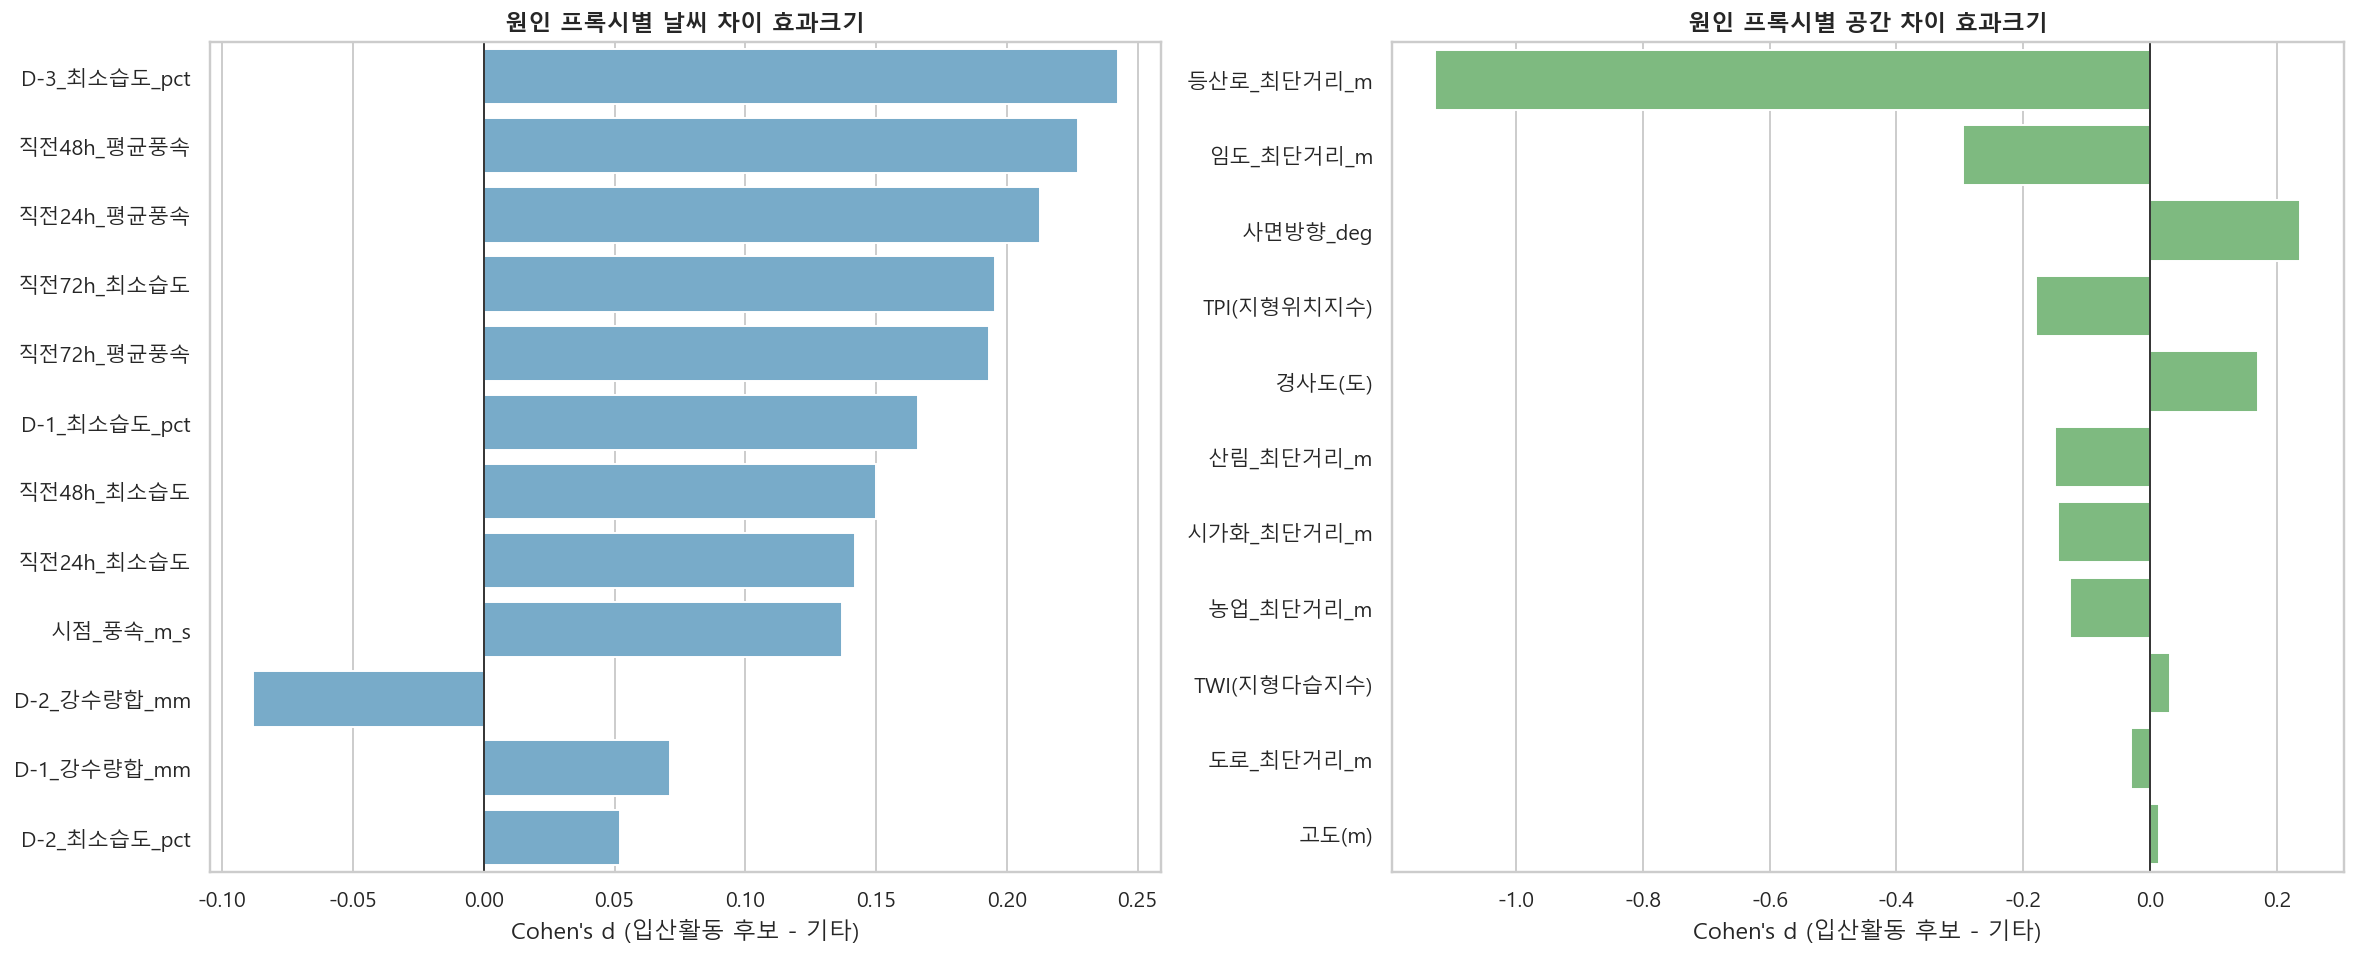

In [13]:
weather_compare_vars = [
    "시점_습도_pct", "시점_풍속_m_s", "시점_강수량_mm",
    "직전24h_최소습도", "직전48h_최소습도", "직전72h_최소습도",
    "직전24h_평균풍속", "직전48h_평균풍속", "직전72h_평균풍속",
    "직전24h_강수량합", "직전48h_강수량합", "직전72h_강수량합",
    "D-1_최소습도_pct", "D-2_최소습도_pct", "D-3_최소습도_pct",
    "D-1_강수량합_mm", "D-2_강수량합_mm", "D-3_강수량합_mm",
    "당일_최대순간풍속_m_s",
]
spatial_compare_vars = [
    "고도(m)", "경사도(도)", "TPI(지형위치지수)", "TWI(지형다습지수)", "사면방향_deg",
    "도로_최단거리_m", "시가화_최단거리_m", "농업_최단거리_m", "산림_최단거리_m", "임도_최단거리_m", "등산로_최단거리_m",
]

weather_internal_stats = mann_whitney_table(
    fire_lc, "원인프록시_500m", "입산활동 발화 후보", "기타 인간활동 발화 후보", weather_compare_vars
)
spatial_internal_stats = mann_whitney_table(
    fire_lc, "원인프록시_500m", "입산활동 발화 후보", "기타 인간활동 발화 후보", spatial_compare_vars
)

display(Markdown("### 원인 프록시별 날씨 변수 비교"))
display(weather_internal_stats.sort_values("FDR").round(4))
display(Markdown("### 원인 프록시별 공간 변수 비교"))
display(spatial_internal_stats.sort_values("FDR").round(4))

cat_test_rows = []
for col in ["기후지형유형", "addr_type", "L1_NAME", "발생시간대구분"]:
    table, stat = cramer_v_table(fire_lc, "원인프록시_500m", col)
    cat_test_rows.append({"범주변수": col, "유효표본수": int(table.to_numpy().sum()), **stat})
cat_tests = pd.DataFrame(cat_test_rows)
cat_tests["FDR"] = bh_fdr(cat_tests["p_value"])
display(Markdown("### 범주형 축과 원인 프록시의 연관성"))
display(cat_tests.round(4))

top_weather_plot = weather_internal_stats.assign(abs_d=weather_internal_stats["Cohen_d"].abs()).sort_values("abs_d", ascending=False).head(12)
top_spatial_plot = spatial_internal_stats.assign(abs_d=spatial_internal_stats["Cohen_d"].abs()).sort_values("abs_d", ascending=False).head(12)
fig, axes = plt.subplots(1, 2, figsize=(17, 7), dpi=140)
sns.barplot(data=top_weather_plot, x="Cohen_d", y="변수", color="#6BAED6", ax=axes[0])
axes[0].axvline(0, color="#333333", lw=1)
axes[0].set_title("원인 프록시별 날씨 차이 효과크기", fontweight="bold")
axes[0].set_xlabel("Cohen's d (입산활동 후보 - 기타)")
axes[0].set_ylabel("")
sns.barplot(data=top_spatial_plot, x="Cohen_d", y="변수", color="#74C476", ax=axes[1])
axes[1].axvline(0, color="#333333", lw=1)
axes[1].set_title("원인 프록시별 공간 차이 효과크기", fontweight="bold")
axes[1].set_xlabel("Cohen's d (입산활동 후보 - 기타)")
axes[1].set_ylabel("")
plt.tight_layout()
save_plot(fig, "02_internal_effect_sizes.png")
plt.show()


> 산불이 발생한 지점들 내부에서 입산활동 발화 후보(등산로/임도 인접)와 기타 인간활동 발화 후보 사이에 발생 당시 및 직전 날씨, 그리고 지형적 특성이 어떻게 달랐는지 비교한 것입니다. (효과크기가 양수(+)이면 입산활동 후보 측이 더 크고, 음수(-)이면 기타 후보 측이 더 큼을 의미합니다.)

1. 날씨 변수 차이 해석
   - 바람(풍속)의 영향력 우세 (양의 효과크기):
     - 직전 24~72시간 동안의 평균 풍속과 산불 발생 시점의 풍속 모두 입산활동 후보군에서 확연히 강하게 나타납니다.
     - 해석: 등산로나 임도는 주로 바람에 노출되기 쉬운 능선(Ridge)이나 열린 계곡 사면을 따라 형성되어 있어 기본적인 바람의 세기가 강합니다. 입산자로 인해 발생한 작은 불씨(담배꽁초, 쓰레기 소각 등)가 실제 산불로 확산되어 기록되기 위해서는 강한 바람이 불씨를 날려 주변 건조한 낙엽층에 착화시키는 과정이 매우 중요하게 작용했음을 시사합니다.
   - 상대적으로 높은 습도 조건 (양의 효과크기):
     - 발생 전(D-1, D-3) 최소습도가 입산활동 후보군에서 오히려 더 높게(덜 건조하게) 나타납니다.
     - 해석: 매우 역설적인 결과로 보일 수 있으나, 인간 행동 측면에서 해석이 가능합니다. 기온이 너무 낮거나 극도로 건조하여 황사/강풍 경보가 내리는 등의 극한 기상 상황에서는 일반 입산객의 등산 활동 자체가 감소합니다. 반면, 날씨가 조금 더 온화하여 습도가 상대적으로 높은 날(예: 봄철 나들이 가기 좋은 날)에 오히려 등산객 입산이 늘어나 실화 원인을 제공하기 때문인 것으로 해석됩니다. 즉, 입산활동 산불은 습도가 극단적으로 낮지 않더라도 강한 바람과 입산객 유입이 결합하면 쉽게 발생할 수 있음을 보여줍니다.
2. 공간 및 지형 변수 차이 해석
   - 프록시 정의에 따른 접근성 (음의 효과크기):
     - 등산로 및 임도 최단거리가 강한 음의 효과크기를 보이는 것은 이 변수들을 기준으로 프록시 집단을 나누었기 때문에 나타나는 당연한 결과입니다.
   - 가파른 경사도와 골짜기(TPI) 지형 (양/음의 효과크기 혼재):
     - 입산활동 후보 산불은 경사도가 더 가파르고, 지형위치지수(TPI)가 음수 방향(골짜기나 평탄한 하부 사면)인 곳에서 발생하는 경향이 있습니다.
     - 해석: 강원도의 등산로나 임도는 보통 골짜기(계곡부)에서 시작해 능선으로 이어지며, 경로 주변의 경사가 급한 편입니다. 계곡 하부나 급경사지에서 입산자 실화로 불이 시작될 경우, 사면을 타고 위로 빠르게 타오르는 '상승 화류(Slope Effect)' 현상 때문에 초동 진화가 어려워지고 대형 산불로 이어지기 쉬운 공간적 취약성을 가집니다.
   - 다른 접근성 지표들과의 연관성:
     - 산림, 시가화, 농업 지역과의 최단거리가 모두 음의 효과크기를 가집니다. 이는 입산활동 후보지가 기본적으로 숲(산림)에 더 가까우면서도 시가화 지역이나 농업 지역과도 일정 거리 이내로 가까운, 즉 **'도시나 농촌 생활권과 맞닿아 있는 산림 경계부'**에서 주로 시작된다는 지리적 특성을 반영합니다.

등산로/임도 인접 산불(입산활동 발화 후보)은 **"완전한 오지 깊은 숲속"**보다는 **"생활권과 가까운 산림 경계부의 가파른 계곡 사면"**에서 주로 시작됩니다.  
날씨 측면에서는 습도가 아주 극단적으로 낮지 않은 날이라 하더라도, 강한 바람이 부는 환경 조건과 **등산객의 실제 입산 활동(날씨가 좋은 날 늘어나는 입산 행동 패턴)**이 가파른 지형적 특성과 결합할 때 불씨가 순식간에 확산되는 매커니즘을 가집니다.  
따라서 단순히 기상청의 건조경보 단계에만 의존해 산불 위험을 감시하기보다, 사람들이 산을 많이 찾는 온화하지만 바람이 강한 날 + 주요 계곡 초입 등산로를 집중 순찰하는 전략이 유효하다는 점을 이 결과가 뒷받침하고 있습니다.


## 4. 같은 기상셀·월·시간대 매칭 비발생 비교

산불 1건마다 같은 기상셀, 같은 월, 같은 시간대의 비발생 시점을 최대 5개 추출한다.
여기서는 공간 조건이 아니라 `산불 발생 시점의 날씨가 같은 배경 조건의 비발생 시점보다 얼마나 위험 방향으로 이동했는지`를 원인 프록시별로 비교한다.


매칭 비발생 대조군 생성 완료
- 매칭 행 수: 17,005
- 산불 1건당 평균 매칭 수: 5.00
- 산불 발생시점과 대조군 중복 여부: False


### 원인 프록시별 산불-매칭비발생 날씨 delta

,변수,원인프록시_500m,유효표본수,산불평균,대조평균,위험방향_delta_평균,위험방향_delta_중앙값,paired_dz,wilcoxon_p,FDR
33,D-1 강수량합,기타 인간활동 발화 후보,2359,0.333200,1.679900,1.3467,0.2980,0.3746,0.0000,0.0000
9,D-1 최소습도,기타 인간활동 발화 후보,2359,33.750198,42.724201,8.9740,10.0940,0.6264,0.0000,0.0000
35,D-2 강수량합,기타 인간활동 발화 후보,2359,0.547100,1.691200,1.1441,0.2220,0.2880,0.0000,0.0000
11,D-2 최소습도,기타 인간활동 발화 후보,2359,38.556400,42.703400,4.1470,5.4260,0.2688,0.0000,0.0000
37,D-3 강수량합,기타 인간활동 발화 후보,2357,0.540600,1.551000,1.0103,0.2020,0.2305,0.0000,0.0000
13,D-3 최소습도,기타 인간활동 발화 후보,2357,36.703300,42.519600,5.8163,9.0100,0.3516,0.0000,0.0000
25,발생시각 강수량,기타 인간활동 발화 후보,2361,0.008800,0.069900,0.0612,0.0000,0.2137,0.0000,0.0000
1,발생시각 습도,기타 인간활동 발화 후보,2361,49.924999,56.554901,6.6300,6.7260,0.3333,0.0000,0.0000
27,직전24h 강수량합,기타 인간활동 발화 후보,2361,0.371100,1.693000,1.3219,0.2980,0.2379,0.0000,0.0000
3,직전24h 최소습도,기타 인간활동 발화 후보,2361,32.290298,41.304600,9.0143,9.2140,0.7026,0.0000,0.0000


### 날씨 delta의 원인 프록시 간 차이

,변수,입산활동_delta평균,기타인간활동_delta평균,delta평균차_입산-기타,Cohen_d,p_value,FDR
6,D-3 최소습도,2.1293,5.8163,-3.6870,-0.2241,0.0000,0.0000
9,직전48h 평균풍속,0.1596,0.0721,0.0875,0.1321,0.0000,0.0000
8,직전24h 평균풍속,0.2172,0.1173,0.0999,0.1164,0.0000,0.0001
3,직전72h 최소습도,4.4084,6.2282,-1.8198,-0.1759,0.0000,0.0001
4,D-1 최소습도,6.8432,8.9740,-2.1308,-0.1459,0.0001,0.0003
7,발생시각 풍속,0.1397,0.0459,0.0938,0.0700,0.0019,0.0061
2,직전48h 최소습도,5.4435,6.8299,-1.3864,-0.1252,0.0031,0.0084
1,직전24h 최소습도,7.6524,9.0143,-1.3619,-0.1042,0.0117,0.0278
10,직전72h 평균풍속,0.0831,0.0559,0.0272,0.0467,0.0321,0.0678
5,D-2 최소습도,3.5017,4.1470,-0.6453,-0.0420,0.0500,0.0949


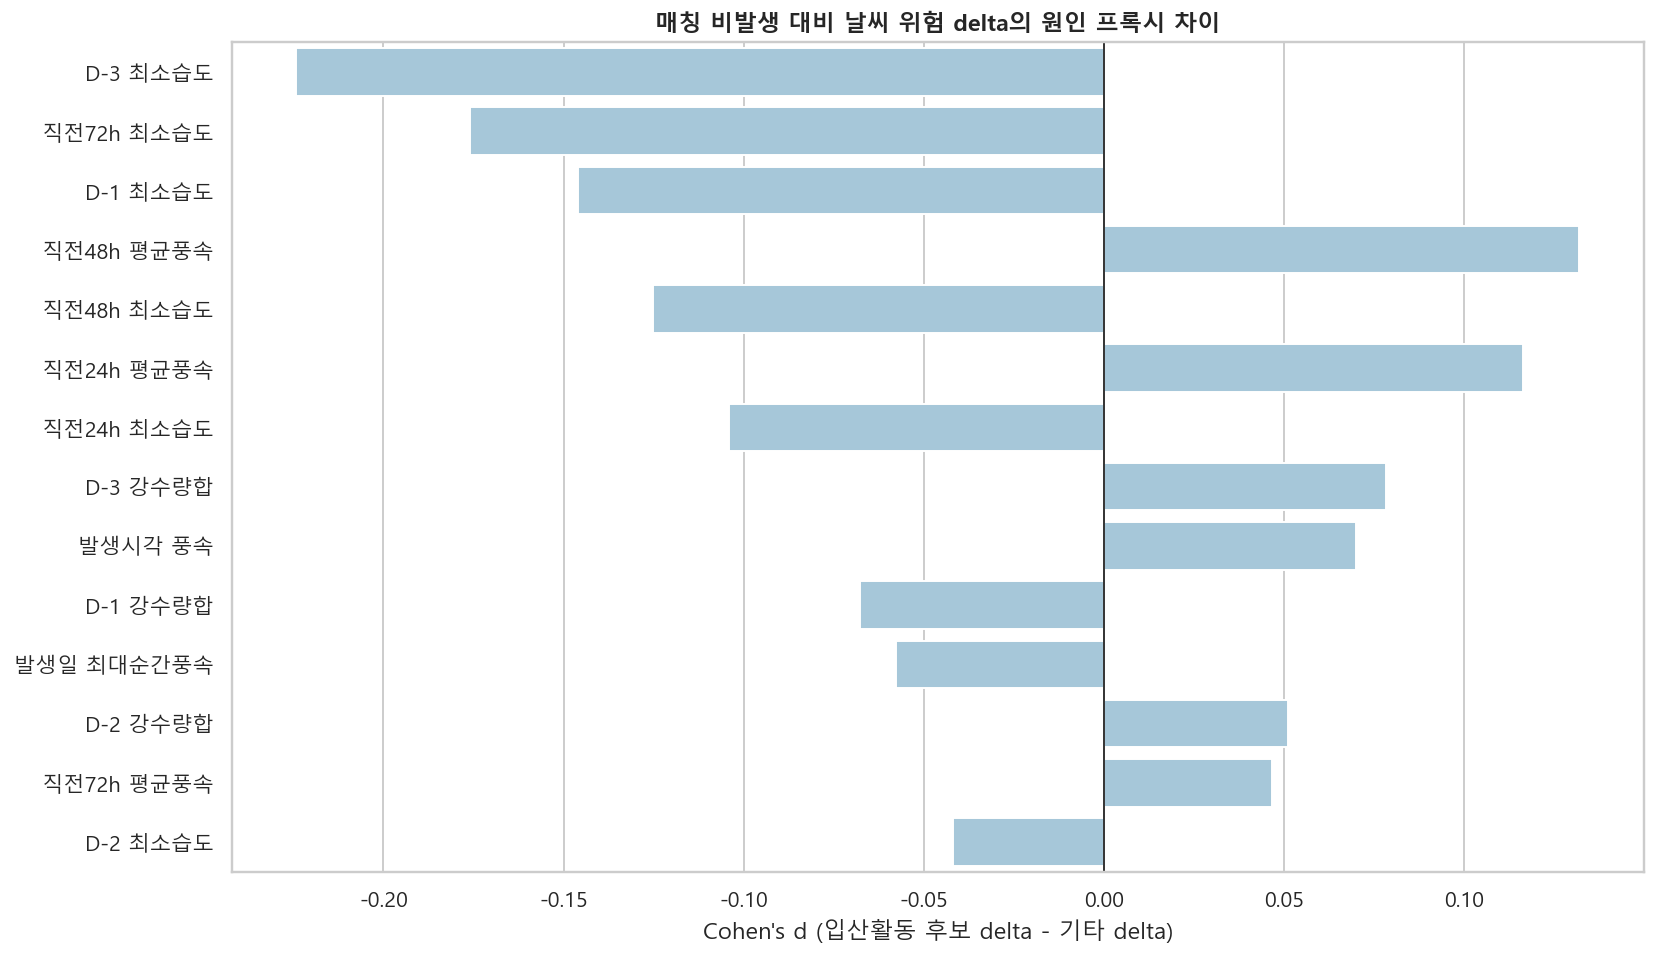

In [14]:
def make_matched_controls(fire_df, hourly_feature_df, n_per_fire=5):
    fire_keys = pd.MultiIndex.from_frame(
        fire_df[["기상셀ID", "발생일시"]].rename(columns={"발생일시": "일시"})
    )
    candidates = hourly_feature_df.copy().reset_index(drop=True)
    hourly_keys = pd.MultiIndex.from_frame(candidates[["기상셀ID", "일시"]])
    candidates = candidates.loc[~hourly_keys.isin(fire_keys)].reset_index(drop=True)
    group_indices = candidates.groupby(["기상셀ID", "월_key", "시간_key"], sort=False).indices
    rng = np.random.default_rng(RANDOM_STATE)
    parts = []
    for _, row in fire_df.iterrows():
        key = (row["기상셀ID"], row["월_key"], row["시간_key"])
        idxs = group_indices.get(key)
        if idxs is None or len(idxs) == 0:
            continue
        take = rng.choice(idxs, size=min(n_per_fire, len(idxs)), replace=False)
        part = candidates.iloc[take].copy()
        part["fire_id"] = row["fire_id"]
        part["source_fire_time"] = row["발생일시"]
        part["원인프록시_500m"] = row["원인프록시_500m"]
        part["control_rank"] = np.arange(1, len(part) + 1)
        parts.append(part)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

matched = make_matched_controls(fire_lc, hourly_features, n_per_fire=5)
matched_keys = pd.MultiIndex.from_frame(matched[["기상셀ID", "일시"]])
fire_keys_check = pd.MultiIndex.from_frame(
    fire_lc[["기상셀ID", "발생일시"]].rename(columns={"발생일시": "일시"})
)
overlap = bool(matched_keys.isin(fire_keys_check).any())
print(f"매칭 비발생 대조군 생성 완료")
print(f"- 매칭 행 수: {len(matched):,}")
print(f"- 산불 1건당 평균 매칭 수: {len(matched) / len(fire_lc):.2f}")
print(f"- 산불 발생시점과 대조군 중복 여부: {overlap}")

weather_specs = [
    ("시점_습도_pct", "발생시각 습도", False),
    ("직전24h_최소습도", "직전24h 최소습도", False),
    ("직전48h_최소습도", "직전48h 최소습도", False),
    ("직전72h_최소습도", "직전72h 최소습도", False),
    ("D-1_최소습도_pct", "D-1 최소습도", False),
    ("D-2_최소습도_pct", "D-2 최소습도", False),
    ("D-3_최소습도_pct", "D-3 최소습도", False),
    ("시점_풍속_m_s", "발생시각 풍속", True),
    ("직전24h_평균풍속", "직전24h 평균풍속", True),
    ("직전48h_평균풍속", "직전48h 평균풍속", True),
    ("직전72h_평균풍속", "직전72h 평균풍속", True),
    ("당일_최대순간풍속_m_s", "발생일 최대순간풍속", True),
    ("시점_강수량_mm", "발생시각 강수량", False),
    ("직전24h_강수량합", "직전24h 강수량합", False),
    ("직전48h_강수량합", "직전48h 강수량합", False),
    ("직전72h_강수량합", "직전72h 강수량합", False),
    ("D-1_강수량합_mm", "D-1 강수량합", False),
    ("D-2_강수량합_mm", "D-2 강수량합", False),
    ("D-3_강수량합_mm", "D-3 강수량합", False),
]

def matched_delta_tables(fire_df, matched_df, specs):
    summary_rows = []
    between_rows = []
    delta_frames = []
    for var, label, higher_is_risk in specs:
        ctrl_mean = matched_df.groupby("fire_id")[var].mean()
        work = fire_df[["fire_id", "원인프록시_500m", var]].copy()
        work["대조평균"] = work["fire_id"].map(ctrl_mean)
        work = work.dropna(subset=[var, "대조평균"])
        if higher_is_risk:
            work["위험방향_delta"] = work[var] - work["대조평균"]
        else:
            work["위험방향_delta"] = work["대조평균"] - work[var]
        work["변수"] = label
        delta_frames.append(work[["fire_id", "원인프록시_500m", "변수", "위험방향_delta"]])
        for cause in CAUSE_ORDER:
            sub = work[work["원인프록시_500m"] == cause]
            if len(sub) < 3:
                continue
            try:
                _, wp = stats.wilcoxon(sub["위험방향_delta"])
            except ValueError:
                wp = np.nan
            summary_rows.append({
                "변수": label,
                "원인프록시_500m": cause,
                "유효표본수": len(sub),
                "산불평균": sub[var].mean(),
                "대조평균": sub["대조평균"].mean(),
                "위험방향_delta_평균": sub["위험방향_delta"].mean(),
                "위험방향_delta_중앙값": sub["위험방향_delta"].median(),
                "paired_dz": paired_dz(sub["위험방향_delta"]),
                "wilcoxon_p": wp,
            })
        a = work.loc[work["원인프록시_500m"] == "입산활동 발화 후보", "위험방향_delta"].dropna()
        b = work.loc[work["원인프록시_500m"] == "기타 인간활동 발화 후보", "위험방향_delta"].dropna()
        if len(a) >= 3 and len(b) >= 3:
            _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
            between_rows.append({
                "변수": label,
                "입산활동_delta평균": a.mean(),
                "기타인간활동_delta평균": b.mean(),
                "delta평균차_입산-기타": a.mean() - b.mean(),
                "Cohen_d": cohen_d(a, b),
                "p_value": p,
            })
    summary = pd.DataFrame(summary_rows)
    if not summary.empty:
        summary["FDR"] = bh_fdr(summary["wilcoxon_p"])
    between = pd.DataFrame(between_rows)
    if not between.empty:
        between["FDR"] = bh_fdr(between["p_value"])
    deltas = pd.concat(delta_frames, ignore_index=True) if delta_frames else pd.DataFrame()
    return summary, between, deltas

matched_summary, matched_between, matched_deltas = matched_delta_tables(fire_lc, matched, weather_specs)
display(Markdown("### 원인 프록시별 산불-매칭비발생 날씨 delta"))
display(matched_summary.sort_values(["원인프록시_500m", "FDR", "변수"]).round(4))
display(Markdown("### 날씨 delta의 원인 프록시 간 차이"))
display(matched_between.sort_values("FDR").round(4))

plot_delta = matched_between.assign(abs_d=matched_between["Cohen_d"].abs()).sort_values("abs_d", ascending=False).head(14)
fig, ax = plt.subplots(figsize=(12, 7), dpi=140)
sns.barplot(data=plot_delta, x="Cohen_d", y="변수", color="#9ECAE1", ax=ax)
ax.axvline(0, color="#333333", lw=1)
ax.set_title("매칭 비발생 대비 날씨 위험 delta의 원인 프록시 차이", fontweight="bold")
ax.set_xlabel("Cohen's d (입산활동 후보 delta - 기타 delta)")
ax.set_ylabel("")
plt.tight_layout()
save_plot(fig, "03_matched_delta_effects.png")
plt.show()


> 단순히 발생점 내부의 단순 기상값을 비교한 앞선 분석과 달리, **"평상시 날씨(대조군)와 비교했을 때, 실제 산불이 날 당시 날씨가 얼마나 극단적으로 굳어졌는지(Delta, 위험 이탈도)"**를 추적하고, 그 이탈도의 패턴이 두 원인 프록시 간에 어떻게 다른지 검정한 고도화된 분석입니다.

1. 산불 발생 시의 기상 이탈 경향 (Wilcoxon 부호순위검정 결과)
   - 두 프록시 그룹 모두 대조군 대비 날씨 이탈도(위험방향_delta)는 모든 핵심 변수에서 **통계적으로 매우 유의미한 양(+)의 값(Wilcoxon p-value 및 FDR = 0.0000)**을 보였습니다. 즉, 입산활동이든 기타 인간활동이든 관계없이 모든 산불은 평상시 계절·시간대 평균보다 훨씬 건조하고 바람이 강하게 부는 날에 발생한다는 대전제를 재확인해 줍니다.
   - 구체적으로는 산불 발생 당일 및 직전 24~72시간 동안 최소습도가 평소보다 큰 폭으로 떨어졌으며, 풍속 및 강수량 결측치(무강우) 역시 평소 수준보다 위험한 방향으로 크게 치우쳐 있었습니다.
2. 두 그룹 간 위험 이탈도(Delta) 차이 분석 (Mann-Whitney U 검정 및 Cohen's d)
   - 두 집단 모두 위험한 날씨에 산불이 났지만, **"그 위험도로 진입하는 날씨 변화의 동력"**에서 두 그룹 간 확연한 대비가 나타납니다. 플롯에 제시된 효과크기(Cohen's d)의 방향성을 중심으로 상세히 해석합니다.
   - 습도 위험 이탈도: 기타 인간활동 후보군이 더 극단적 건조 요구 (음의 효과크기)
     - 대상 변수: D-3 최소습도, 직전 72h 최소습도, D-1 최소습도, 직전 48h/24h 최소습도 등 습도 관련 거의 모든 변수 (Cohen's d: -0.224 ~ -0.104)
     - 해석: 이 습도 변수들의 효과크기가 모두 음수(-) 방향으로 큽니다. 이는 **'기타 인간활동 후보군'**의 산불 발생 시 습도 저하 폭(Delta)이 '입산활동 후보군'보다 훨씬 더 크고 극단적이었다는 뜻입니다.
     - 의미: 생활권 주변의 소각, 쓰레기 방화 등의 기타 인간활동 산불은 습도가 평소 기준치보다 대단히 많이 떨어져 바짝 마른 상태여야만 작은 불씨가 산불로 번지는 반면, 등산로/임도 인근의 입산활동 산불은 습도가 평소보다 약간만 낮아지는 약한 건조 상태에서도 산불로 쉽게 발화될 수 있음을 방증합니다.
   - 풍속 위험 이탈도: 입산활동 후보군이 더 강력한 바람 변동 요구 (양의 효과크기)
     - 대상 변수: 직전 48h 평균풍속, 직전 24h 평균풍속, 발생시각 풍속 등 (Cohen's d: +0.070 ~ +0.132)
     - 해석: 풍속 변수들은 효과크기가 양수(+) 방향을 보입니다. 즉, 평상시 바람 세기 대비 산불 발생 당일 풍속이 위험한 방향으로 급증한 폭(Delta)은 **'입산활동 후보군'**에서 훨씬 더 컸습니다.
     - 의미: 등산로/임도 인근 산불은 건조도보다는 **"바람의 급격한 활성화"**가 발화와 확산의 더 지배적인 방동력(Trigger)이 됨을 뜻합니다. 평소보다 유독 바람이 세차게 부는 아노말리(이상 기류)가 발생했을 때, 등산로 주변의 미세한 불씨가 바람을 타고 숲 안쪽으로 번지며 산불로 이어지는 패턴입니다.
   - 강수량 및 기타 변수의 영향 (미미한 효과크기)
     - 대상 변수: D-3/D-2 강수량합, 당일 최대순간풍속 등
     - 해석: 강수량 관련 변수들은 효과크기가 매우 작고(+0.05 내외), 발생일 최대순간풍속의 이탈 차이 역시 변별력이 크지 않습니다. 이는 강수 여부 자체가 양측 모두에 공통적인 전제조건(비가 오지 않아야 함)이기 때문이며, 돌풍(순간풍속)보다는 지속적인 평균 풍속의 증가가 입산 산불 확산에 더 기여함을 뜻합니다.

본 매칭 분석을 통해 입산활동 산불의 날씨적 메커니즘을 보다 정밀하게 규명할 수 있습니다.
   - 습도 기준치 완화 필요: 산불 예방 예보를 짤 때, 등산로 및 임도 구역은 일반 생활권 주변 구역보다 습도 경보 기준을 조금 더 느슨하게(즉, 덜 건조한 상태여도 위험으로 분류) 적용해야 합니다. 아주 바짝 마른 날이 아니더라도 입산객 실화는 충분히 발생할 수 있기 때문입니다.
  - 풍속 가중치 부여: 반대로 등산로/임도 구역은 **직전 24~48시간 동안의 풍속 증가 아노말리(평소 대비 바람이 세진 정도)**에 가중치를 훨씬 높게 두어 위험도를 평가해야 합니다. 평소보다 바람이 거세지는 시점이 바로 입산자 실화가 실제 대형 산불 재해로 전환되는 가장 취약한 골든타임이기 때문입니다.

## 5. 등산로·임도 선형 비발생 공간 샘플

등산로와 임도 선형을 500m 간격으로 샘플링한다. 이 샘플은 실제 비발생 기록이 아니라 `입산활동이 가능한 배경 공간`이다.
기상값은 기상셀 단위라 같은 셀 안의 선형 샘플끼리 동일한 시간 날씨를 공유하므로, 여기서는 공간·지형 대조에 집중한다.


- 선형샘플 도로 최단거리 완료
- 선형샘플 임도 최단거리 완료
- 선형샘플 등산로 최단거리 완료
- 선형샘플 산림지역 최단거리 완료
- 선형샘플 시가화건조지역 최단거리 완료
- 선형샘플 농업지역 최단거리 완료
선형 비발생 공간 샘플 생성 완료: 57.3초
- 등산로 샘플: 16,787
- 임도 샘플: 10,963
- 기상셀 미매칭 선형 샘플 제외: 198
- 선형 비발생 분석 샘플: 27,552
- 입산활동 후보 산불: 1,040


,변수,전체행,유효표본수,결측수,결측률_pct
0,기상셀ID,27552,27552,0,0.00
1,기후지형유형,27552,27552,0,0.00
2,L1_NAME,27552,27552,0,0.00
3,DEM고도_m,27552,27478,74,0.27
4,DEM경사도_deg,27552,27159,393,1.43
5,도로_최단거리_m,27552,27552,0,0.00
6,임도_최단거리_m,27552,27552,0,0.00
7,등산로_최단거리_m,27552,27552,0,0.00


### 입산활동 후보 산불 vs 선형 비발생 공간 샘플

,변수,입산활동 후보 산불_유효표본,선형비발생샘플_유효표본,입산활동 후보 산불_중앙값,선형비발생샘플_중앙값,입산활동 후보 산불_평균,선형비발생샘플_평균,Cohen_d,p_value,FDR
5,산림_최단거리_m,1040,27552,45.5352,1.3275,283.1592,165.6600,0.1037,0.0,0.0
0,DEM고도_m,1040,27478,156.2817,552.2764,233.9230,567.1742,-1.0817,0.0,0.0
1,DEM경사도_deg,1040,27159,4.7867,13.3428,6.7018,13.6966,-0.9909,0.0,0.0
4,농업_최단거리_m,1040,27552,57.4348,399.1880,320.5065,725.3631,-0.3199,0.0,0.0
6,임도_최단거리_m,1040,27552,3257.0139,522.1404,3986.8285,1893.7270,0.7572,0.0,0.0
7,등산로_최단거리_m,1040,27552,230.8161,0.0000,425.2811,666.1741,-0.2004,0.0,0.0
3,시가화_최단거리_m,1040,27552,0.9547,6.3530,246.1480,382.0002,-0.1143,0.0,0.0
2,도로_최단거리_m,1040,27552,1.9561,1.5682,28.1570,215.0549,-0.4639,0.0,0.0


L1_NAME,나지,농업지역,미분류,산림지역,수역,습지,시가화건조지역,초지
sample_type,,,,,,,,
선형비발생샘플,6.38,0.66,3.81,41.1,0.05,0.32,43.60,4.10
입산활동 후보 산불,10.38,7.69,3.94,14.9,0.48,1.63,45.58,15.38


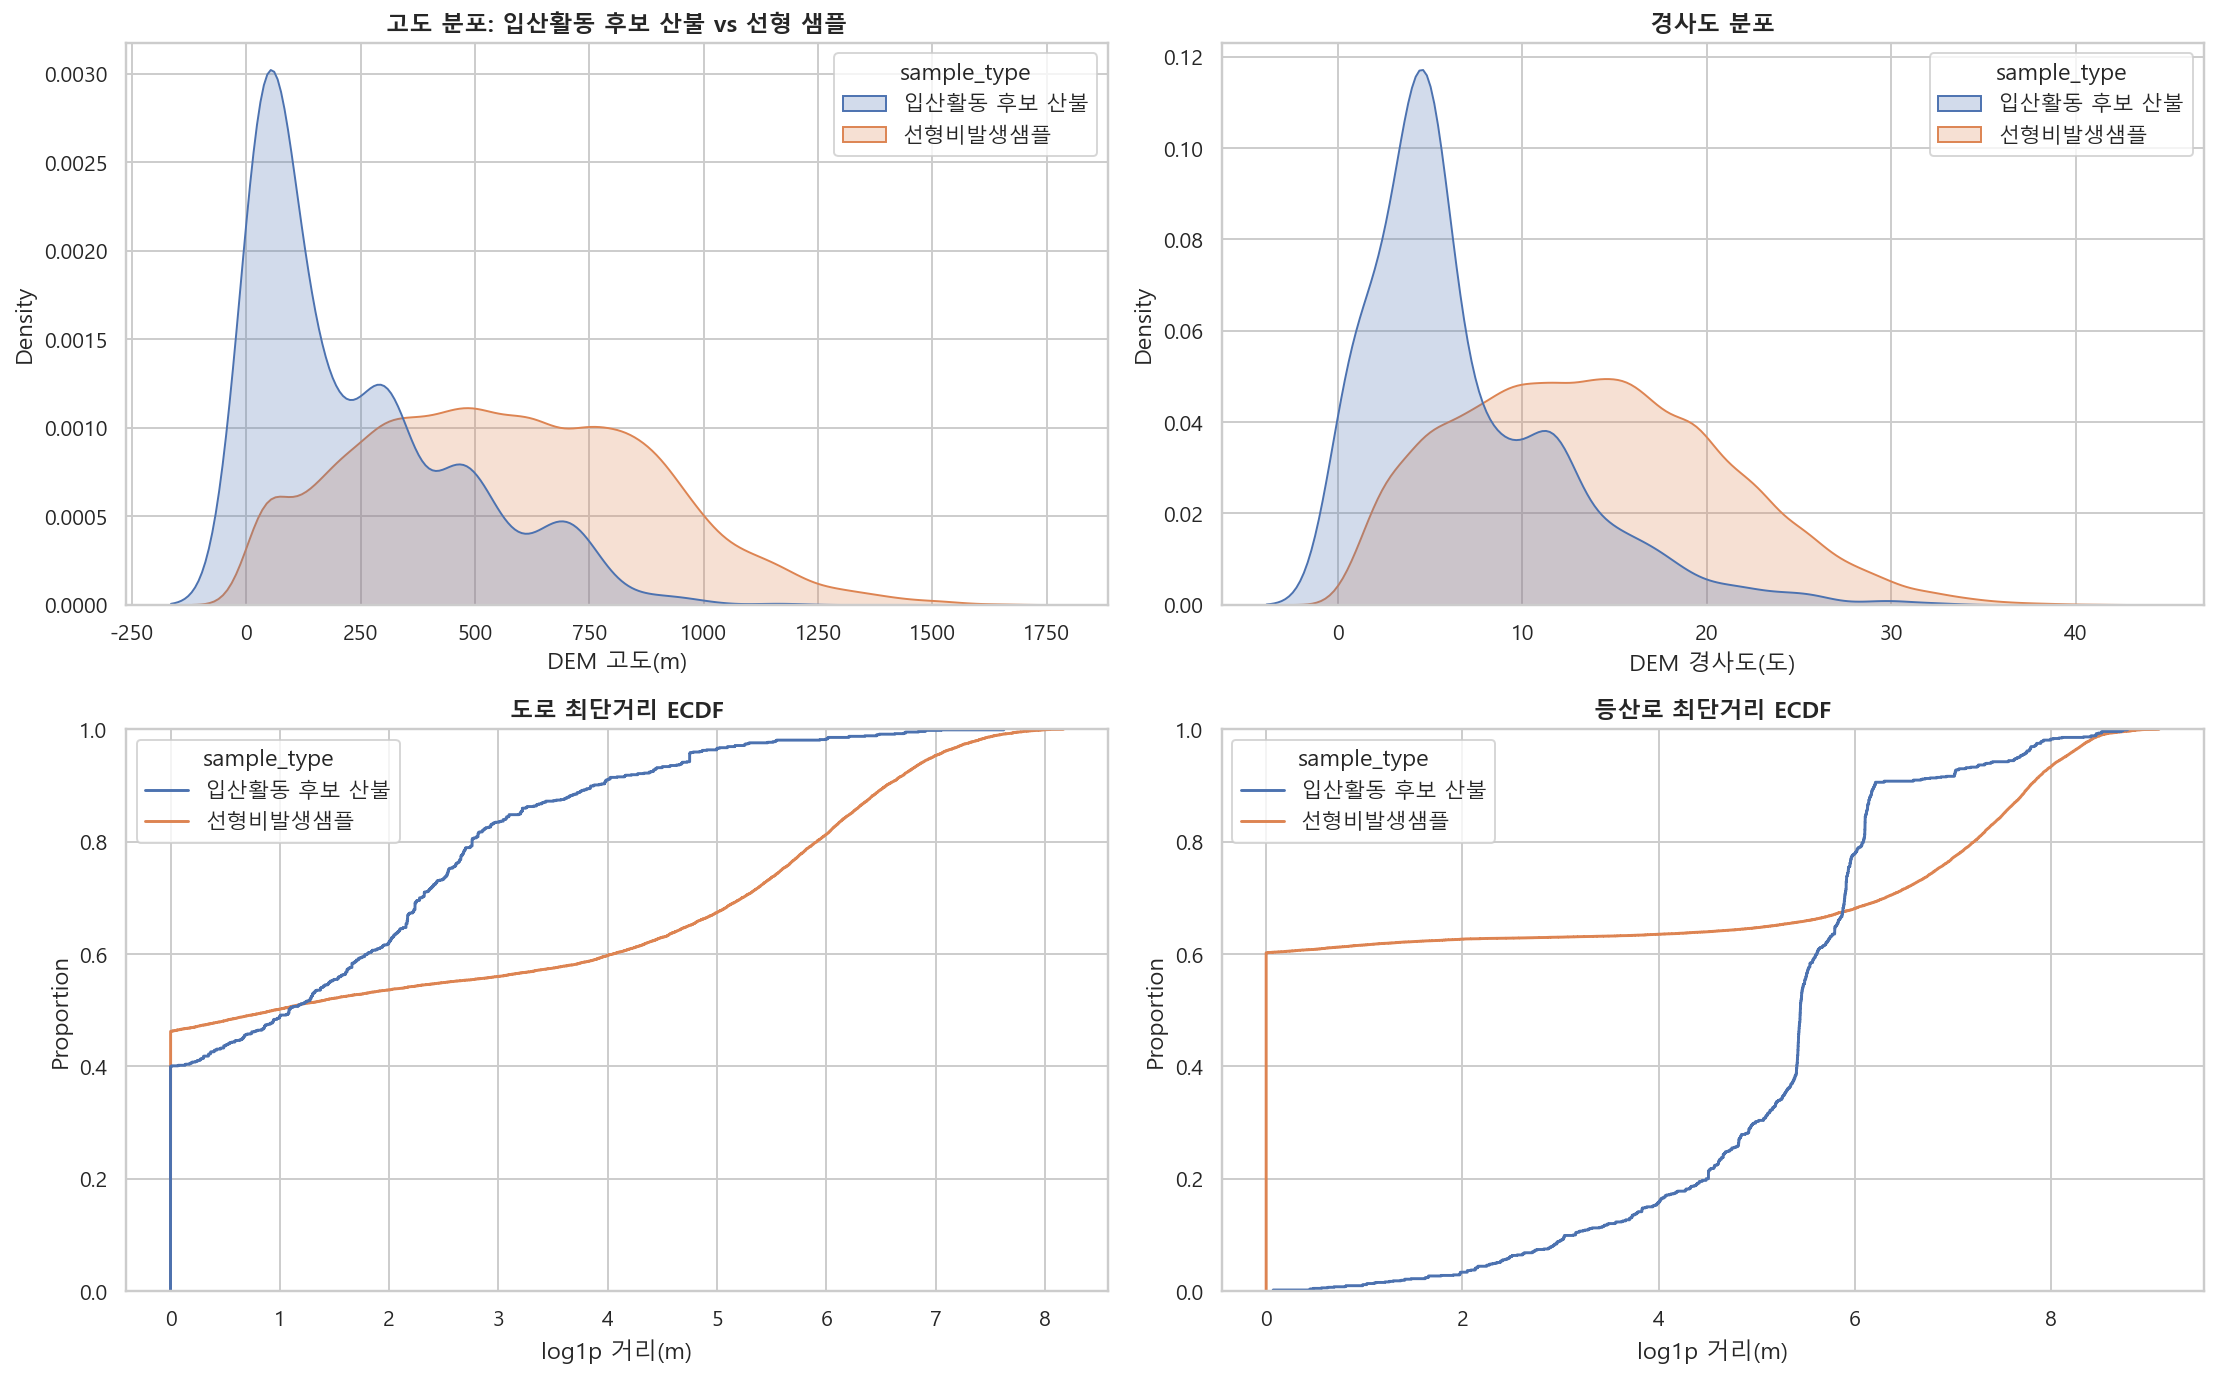

In [15]:
t0 = time.time()
trail_samples = sample_line_points(trail, "등산로", step_m=500)
imdo_samples = sample_line_points(imdo, "임도", step_m=500)
line_samples = gpd.GeoDataFrame(
    pd.concat([trail_samples, imdo_samples], ignore_index=True),
    geometry="geometry",
    crs=land.crs,
)
grid_land = grid.to_crs(land.crs)
line_samples = gpd.sjoin(
    line_samples,
    grid_land[["기상셀ID", "기후권역", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"])
line_unmatched = int(line_samples["기상셀ID"].isna().sum())
line_samples = line_samples[line_samples["기상셀ID"].notna()].copy()
line_samples = line_samples.merge(climate_type[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left")

line_lc = gpd.sjoin(
    line_samples,
    land[["L1_NAME", "L2_NAME", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"])
line_lc = line_lc.drop_duplicates(subset="sample_id").reset_index(drop=True)
line_lc["L1_NAME"] = line_lc["L1_NAME"].fillna("미분류")
line_lc["L2_NAME"] = line_lc["L2_NAME"].fillna("미분류")

for label, col in distance_specs:
    geom_arr, tree = target_indices[label]
    line_lc[col] = nearest_distance_from_index(line_lc, geom_arr, tree, f"선형샘플 {label}")

with rasterio.open(SPATIAL_DIR / "강원도_DEM_데이터.tif") as src:
    dem_arr = src.read(1, masked=True).astype("float64").filled(np.nan)
    transform = src.transform
    dem_crs = src.crs
    xres = abs(transform.a)
    yres = abs(transform.e)
    gy, gx = np.gradient(dem_arr, yres, xres)
    slope_arr = np.degrees(np.arctan(np.sqrt(gx ** 2 + gy ** 2)))

line_dem = line_lc.to_crs(dem_crs)
line_lc["DEM고도_m"] = sample_array_at_points(line_dem, dem_arr, transform)
line_lc["DEM경사도_deg"] = sample_array_at_points(line_dem, slope_arr, transform)

entry_fire = fire_lc[fire_lc["원인프록시_500m"] == "입산활동 발화 후보"].copy()
entry_fire["sample_type"] = "입산활동 후보 산불"
entry_fire["sample_id"] = entry_fire["fire_id"]
entry_fire["source_line"] = "산불발생점"
entry_fire["DEM고도_m"] = entry_fire["고도(m)"]
entry_fire["DEM경사도_deg"] = entry_fire["경사도(도)"]
line_lc["sample_type"] = "선형비발생샘플"

line_compare_cols = [
    "sample_id", "sample_type", "source_line", "기상셀ID", "기후지형유형", "L1_NAME", "L2_NAME",
    "DEM고도_m", "DEM경사도_deg", "도로_최단거리_m", "시가화_최단거리_m", "농업_최단거리_m", "산림_최단거리_m", "임도_최단거리_m", "등산로_최단거리_m", "geometry",
]
line_compare = gpd.GeoDataFrame(
    pd.concat([
        entry_fire[line_compare_cols],
        line_lc[line_compare_cols],
    ], ignore_index=True),
    geometry="geometry",
    crs=land.crs,
)

line_compare_vars = [
    "DEM고도_m", "DEM경사도_deg", "도로_최단거리_m", "시가화_최단거리_m", "농업_최단거리_m", "산림_최단거리_m", "임도_최단거리_m", "등산로_최단거리_m",
]
line_spatial_stats = mann_whitney_table(line_compare, "sample_type", "입산활동 후보 산불", "선형비발생샘플", line_compare_vars)
line_lc_table = pd.crosstab(line_compare["sample_type"], line_compare["L1_NAME"], normalize="index").mul(100)
t1 = time.time()
print(f"선형 비발생 공간 샘플 생성 완료: {t1 - t0:.1f}초")
print(f"- 등산로 샘플: {len(trail_samples):,}")
print(f"- 임도 샘플: {len(imdo_samples):,}")
print(f"- 기상셀 미매칭 선형 샘플 제외: {line_unmatched:,}")
print(f"- 선형 비발생 분석 샘플: {(line_compare['sample_type'] == '선형비발생샘플').sum():,}")
print(f"- 입산활동 후보 산불: {(line_compare['sample_type'] == '입산활동 후보 산불').sum():,}")
display(valid_summary(line_lc, ["기상셀ID", "기후지형유형", "L1_NAME", "DEM고도_m", "DEM경사도_deg", "도로_최단거리_m", "임도_최단거리_m", "등산로_최단거리_m"]))
display(Markdown("### 입산활동 후보 산불 vs 선형 비발생 공간 샘플"))
display(line_spatial_stats.sort_values("FDR").round(4))
display(line_lc_table.round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=140)
sns.kdeplot(data=line_compare, x="DEM고도_m", hue="sample_type", common_norm=False, fill=True, alpha=0.25, ax=axes[0, 0])
axes[0, 0].set_title("고도 분포: 입산활동 후보 산불 vs 선형 샘플", fontweight="bold")
axes[0, 0].set_xlabel("DEM 고도(m)")
sns.kdeplot(data=line_compare, x="DEM경사도_deg", hue="sample_type", common_norm=False, fill=True, alpha=0.25, ax=axes[0, 1])
axes[0, 1].set_title("경사도 분포", fontweight="bold")
axes[0, 1].set_xlabel("DEM 경사도(도)")
for ax, col, title in [
    (axes[1, 0], "도로_최단거리_m", "도로 최단거리 ECDF"),
    (axes[1, 1], "등산로_최단거리_m", "등산로 최단거리 ECDF"),
]:
    plot_df = line_compare[[col, "sample_type"]].dropna().copy()
    plot_df[f"log1p_{col}"] = np.log1p(plot_df[col])
    sns.ecdfplot(data=plot_df, x=f"log1p_{col}", hue="sample_type", ax=ax)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("log1p 거리(m)")
plt.tight_layout()
save_plot(fig, "04_line_sample_contrast.png")
plt.show()


> 강원도 전체의 등산로와 임도망을 500m 간격으로 촘촘히 쪼개어 만든 **배경 공간(선형 비발생 샘플)**과, 실제 발생한 입산활동 후보 산불의 공간적 특성을 대조한 것입니다.
> 강원도 전체 등산로/임도가 가지는 '지리적 배경 환경'과 비교해 **실제 산불이 터지는 입산 환경의 공간적 바이어스(Selection Bias)**를 찾아내는 것이 핵심 의도입니다.

1. 고도와 경사도의 현격한 격차
   - 강원도의 등산로와 임도망(주황색)은 산악 지형을 따라 고도가 높고(중앙값 약 550m) 경사도 가파른(중앙값 약 13도) 곳까지 고르게 뻗어 있습니다.
   - 하지만 실제 발생한 산불(파란색)은 해발고도 200m 이하의 저지대와 5도 미만의 아주 평탄한 완경사지에 극단적으로 집중되어 있습니다. 효과크기(Cohen's d) 역시 고도(-1.08)와 경사도(-0.99) 모두 매우 강력한 음의 효과를 보여줍니다.
   - 산불 감시망이 험준한 깊은 산속 고지대 능선이나 급경사지를 중심으로 순찰을 도는 것은 비효율적일 수 있습니다. 입산객의 절대적인 통행량과 행동반경이 접근성이 좋은 저지대 입구 및 평탄한 사면에 편중되어 있기 때문에, 실제 화재 거점은 산 초입부의 저지대 완경사지에 고도로 쏠려 발생하게 됩니다.
2. 도로 및 등산로 최단거리 분포
   - 일반 도로에 밀착된 발생 패턴
     - 실제 산불 지점(파란색)은 일반 도로와의 거리가 매우 가깝게 형성되어 누적분포 그래프가 왼쪽으로 급격히 상승합니다. 반면 전체 등산로/임도망(주황색)은 도로에서 수 킬로미터 떨어진 심산유곡 구간이 많아 완만하게 우측으로 이어집니다.
     - 의미: 산불은 등산로 깊은 안쪽 구간보다 "차량으로 이동 가능한 도로망과 등산로가 만나는 진입부" 근처에서 압도적으로 많이 시작됩니다.
   - 등산로 선형 대비 이격 분포
     - 대조군 샘플(주황색)은 애초에 등산로 선형 위에서 직접 샘플링한 비율이 높아 거리=0m 지점(log1p = 0)에서 바로 약 60%의 수직 상승을 보입니다.
     - 반면, 실제 산불 발생점(파란색)은 등산로 바로 위(0m)보다는 등산로 주변 수십에서 수백 미터 반경에 부드러운 곡선을 그리며 고르게 퍼져 있습니다.
     - 의미: 발화의 시작점 자체가 등산로 정중앙 바닥이 아니라, 등산로 주변의 휴식처, 전망대, 산림 인접 경계 밭자락 등 등산로 주변의 인접 활동 반경 내에서 발생해 사면으로 번지기 때문입니다.
3. 토지피복(소분류) 구성을 통한 인간 활동의 흔적
   - 경계면(Ecotone) 중심의 발화 취약성:
     - 배경 공간(대조군)은 빽빽한 수림을 관통하므로 산림지역의 비중이 매우 높습니다.
     - 그러나 실제 산불 발생 지점은 산림 한가운데보다는 초지(풀밭), 나지(맨땅), 농업지역의 비율이 배경 분포에 비해 확연하게 우세합니다.
   - 입산 산불은 단순한 밀폐림 내부보다 나무가 듬성듬성하고 풀이 깔린 곳(초지, 나지)이나 농경지와 산이 맞닿는 경계부에서 시작될 가능성이 큽니다. 가연물 측면에서 마른 풀과 잔가지가 많아 불씨가 붙기 쉽고, 인간 활동(휴식, 취사, 무단 소각 등)의 전이가 물리적으로 수월한 환경이기 때문입니다.

강원도 전체 등산로와 임도망은 깊은 산속 고지대 급경사지까지 넓게 분포해 있지만, 실제 입산 요인의 산불은 "일반 도로와 맞닿아 있는 저지대의 평탄한 등산로 초입부", 그리고 **"산림 내부가 아닌 초지·나지 등 경계면 공간"**에서 지리적으로 선택되어 일어납니다.  
따라서 등산객 실화 예방을 위한 감시 카메라 설치나 예방 초소 배치, 인력 순찰 등의 공간적 우선순위는 산림 깊숙한 임도망 전체를 커버하려 하기보다는, 국도/지방도와 등산로가 교차하는 초입 노드(Node) 및 생활권 인근 저지대 완경사 진입로에 집중하는 것이 자원 대비 예방 효과를 극대화할 수 있는 과학적 방안임을 보여줍니다.



## 6. 기후지형유형 × 번지유형 층화 분석

전체 결과를 우선 해석하고, 각 층에서 두 원인 프록시가 모두 30건 이상인 조합만 본문 해석 후보로 둔다.
희소 조합은 표본 부족으로 p-value와 효과크기를 과대 해석하지 않는다.


### 층화별 원인 프록시 표본 수

원인프록시_500m,기후지형유형,addr_type,입산활동 발화 후보,기타 인간활동 발화 후보,해석가능층_n30
0,고지·산간형,일반번지,202.0,211.0,True
1,고지·산간형,임야번지(산),66.0,143.0,True
2,영동 해안형,일반번지,422.0,553.0,True
3,영동 해안형,임야번지(산),92.0,154.0,True
4,영서 내륙형,일반번지,178.0,1050.0,True
5,영서 내륙형,임야번지(산),80.0,250.0,True


### n>=30 층화 조합의 원인 프록시별 변수 차이

,기후지형유형,addr_type,변수,입산활동 발화 후보_유효표본,기타 인간활동 발화 후보_유효표본,입산활동 발화 후보_중앙값,기타 인간활동 발화 후보_중앙값,Cohen_d,p_value,해석가능층,FDR
10,고지·산간형,일반번지,등산로_최단거리_m,202,211,356.6528,1203.1587,-1.2715,0.0000,True,0.0000
8,고지·산간형,일반번지,도로_최단거리_m,202,211,1.7165,9.0557,-0.7098,0.0000,True,0.0000
9,고지·산간형,일반번지,임도_최단거리_m,202,211,2210.0428,2776.0231,-0.4889,0.0000,True,0.0000
5,고지·산간형,일반번지,고도(m),202,211,445.0426,524.7123,-0.3288,0.0002,True,0.0005
0,고지·산간형,일반번지,시점_습도_pct,202,211,50.0250,58.3700,-0.3115,0.0006,True,0.0014
...,...,...,...,...,...,...,...,...,...,...,...
57,영서 내륙형,임야번지(산),D-1_최소습도_pct,80,250,34.2800,32.5350,0.0918,0.0888,True,0.1332
62,영서 내륙형,임야번지(산),TWI(지형다습지수),70,198,2.9665,2.8296,-0.1960,0.1257,True,0.1804
55,영서 내륙형,임야번지(산),시점_습도_pct,80,250,46.2750,41.5600,0.1589,0.1881,True,0.2492
58,영서 내륙형,임야번지(산),시점_풍속_m_s,80,250,2.6500,2.0300,0.2505,0.1992,True,0.2578


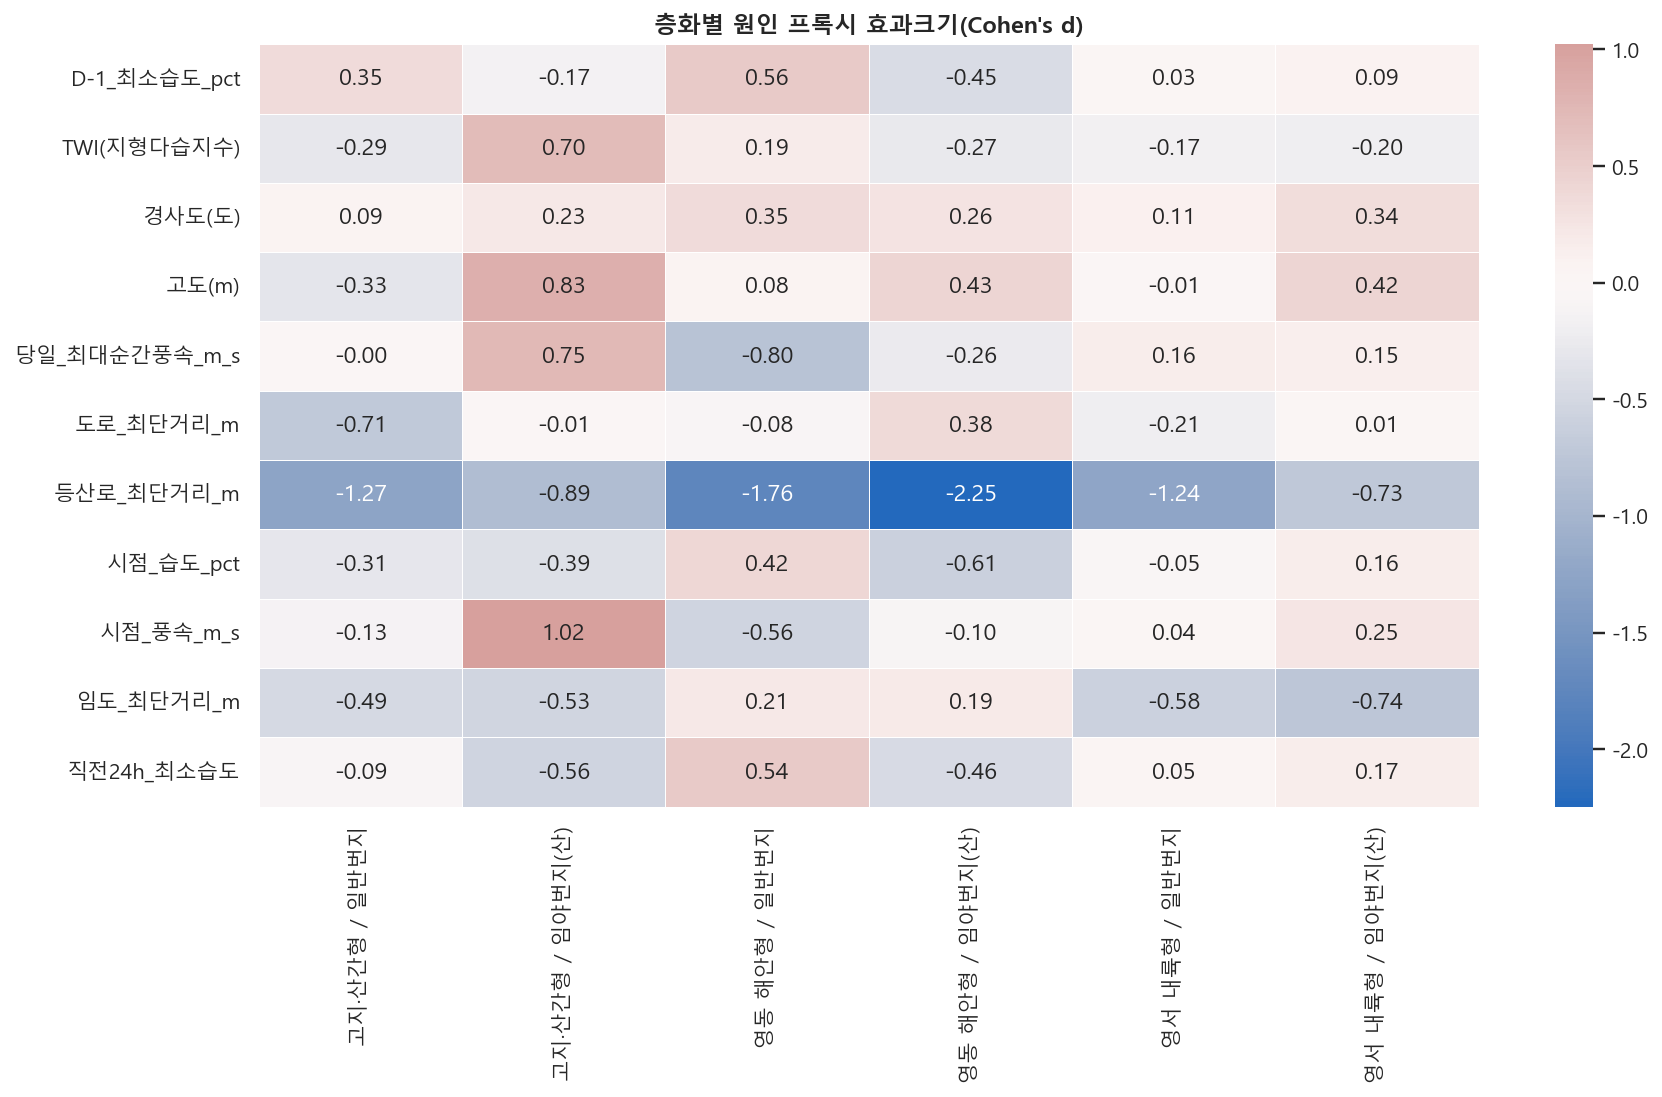

In [16]:
def stratified_mw_table(df, strata_cols, group_col, group_a, group_b, variables, min_n=30):
    rows = []
    for keys, sub in df.groupby(strata_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        counts = sub[group_col].value_counts()
        n_a = int(counts.get(group_a, 0))
        n_b = int(counts.get(group_b, 0))
        eligible = n_a >= min_n and n_b >= min_n
        for var in variables:
            if var not in sub.columns:
                continue
            a = sub.loc[sub[group_col] == group_a, var].dropna()
            b = sub.loc[sub[group_col] == group_b, var].dropna()
            if len(a) < min_n or len(b) < min_n:
                continue
            _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
            row = {col: val for col, val in zip(strata_cols, keys)}
            row.update({
                "변수": var,
                f"{group_a}_유효표본": len(a),
                f"{group_b}_유효표본": len(b),
                f"{group_a}_중앙값": a.median(),
                f"{group_b}_중앙값": b.median(),
                "Cohen_d": cohen_d(a, b),
                "p_value": p,
                "해석가능층": eligible,
            })
            rows.append(row)
    out = pd.DataFrame(rows)
    if not out.empty:
        out["FDR"] = bh_fdr(out["p_value"])
    return out

strata_counts = (
    fire_lc.groupby(["기후지형유형", "addr_type", "원인프록시_500m"])
    .size()
    .rename("건수")
    .reset_index()
)
strata_count_pivot = (
    strata_counts.pivot_table(index=["기후지형유형", "addr_type"], columns="원인프록시_500m", values="건수", fill_value=0)
    .reindex(columns=CAUSE_ORDER, fill_value=0)
    .reset_index()
)
strata_count_pivot["해석가능층_n30"] = (strata_count_pivot["입산활동 발화 후보"] >= 30) & (strata_count_pivot["기타 인간활동 발화 후보"] >= 30)
display(Markdown("### 층화별 원인 프록시 표본 수"))
display(strata_count_pivot)

strata_vars = [
    "시점_습도_pct", "직전24h_최소습도", "D-1_최소습도_pct", "시점_풍속_m_s", "당일_최대순간풍속_m_s",
    "고도(m)", "경사도(도)", "TWI(지형다습지수)", "도로_최단거리_m", "임도_최단거리_m", "등산로_최단거리_m",
]
stratified_stats = stratified_mw_table(
    fire_lc,
    ["기후지형유형", "addr_type"],
    "원인프록시_500m",
    "입산활동 발화 후보",
    "기타 인간활동 발화 후보",
    strata_vars,
    min_n=30,
)
display(Markdown("### n>=30 층화 조합의 원인 프록시별 변수 차이"))
display(stratified_stats.sort_values(["기후지형유형", "addr_type", "FDR"]).round(4))

if not stratified_stats.empty:
    heat = stratified_stats.assign(층=stratified_stats["기후지형유형"].astype(str) + " / " + stratified_stats["addr_type"].astype(str))
    heat = heat.pivot_table(index="변수", columns="층", values="Cohen_d")
    fig, ax = plt.subplots(figsize=(13, 8), dpi=140)
    sns.heatmap(heat, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.4, ax=ax)
    ax.set_title("층화별 원인 프록시 효과크기(Cohen's d)", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    save_plot(fig, "05_stratified_effects.png")
    plt.show()


> 강원도의 기후지형(고지·산간형, 영동 해안형, 영서 내륙형)과 행정 주소(일반번지, 임야번지)를 조합한 **6개의 세부 집단(층)**을 나누고, 각 집단 내부에서 원인 프록시(입산활동 후보 vs 기타 인간활동 후보)별로 날씨 및 지형 환경의 편차를 계산하여 히트맵으로 시각화한 것입니다.

1. 세부 층(Strata)별 날씨·지형 융합 해석
   - 고지·산간형 / 일반번지 층
     - 공간적 특징: 입산활동 후보 산불은 일반 산불에 비해 일반 도로망과 임도에 훨씬 더 밀착되어 발생하며, 전체 고지대 안에서도 상대적으로 해발고도가 낮은 지대에 집중됩니다.
     - 날씨 패턴: 산불 발생 당일에는 입산활동 후보군의 대기 습도가 유의미하게 더 건조하지만, 직전 날씨(D-1 습도)는 오히려 덜 건조한 편이었습니다.
     - 융합 해석: 이 층의 입산 산불은 고지대 깊은 산맥 내부보다는, 사람이 쉽게 차량으로 접근할 수 있는 산맥 초입부 계곡지대나 등산로 진입 도로변에 강하게 국한됩니다. 또한 전날 날씨가 아주 거칠고 건조하지 않더라도, 당일 낮 동안 기온이 오르고 일시적으로 건조해지는 틈을 타 입산객 요인으로 발화하는 경향을 보여줍니다.
   - 고지·산간형 / 임야번지(산) 층
     - 공간적 특징: 입산활동 후보 산불이 일반 산불 대비 더 높은 해발고도에 분포합니다. 또한 지형의 물 빠짐 경로를 보여주는 다습지수(TWI)가 높고 경사가 가파른 등산로 주변에 쏠려 있습니다.
     - 날씨 패턴: 6개 층 중 **바람(풍속 및 순간풍속)의 효과크기가 가장 극대화(Cohen's d > 1.0)**되어 나타나며, 발생 당시 대기 습도와 직전 24시간 습도 역시 일반 산불 대비 확연히 더 건조합니다.
     - 융합 해석: 깊은 산림지대 내부(임야번지)로 들어갈 경우, 입산활동 산불은 능선을 따라 길게 뻗은 고지대 등산로 주변에서 발생합니다. 고지대 능선은 바람이 막힘없이 부는 통로이기 때문에, 발화 시점에 매우 강력한 강풍과 극단적인 대기 건조가 동시에 결합하는 기상 이벤트가 있을 때만 미세한 불씨가 실제 기록되는 산불로 급격히 확산됨을 나타냅니다.
   - 영동 해안형 / 일반번지 층
     - 공간적 특징: 등산로와의 거리가 극도로 밀접한 특징을 공유하면서도, 사면 경사가 가파른 곳(산자락 초입)에 쏠려 있습니다.
     - 날씨 패턴: 풍속(평균 풍속 및 최대순간풍속)은 오히려 입산활동 후보군이 유의미하게 더 약하고, 습도는 발생 당일과 직전 24시간 모두 입산활동 후보군이 훨씬 더 축축(덜 건조)했습니다.
     - 융합 해석: 영동 해안 지역의 일반 번지에서 발생하는 '기타 인간활동 산불'은 봄철 양간지풍(극단적으로 건조한 서풍 돌풍)이 부는 최악의 기상 상황에서 농가 소각 등으로 인해 발생하는 초대형 바람 산불이 주를 이룹니다. 반면, 이 지역의 입산 산불은 바람이 비교적 잔잔하고 날씨가 쾌적하여 **사람들이 가볍게 등산을 나서기 좋은 온화한 날(상대적으로 습도가 높은 날)**에 주로 등산로 입구 사면에서 발생하므로 기상 이탈도가 일반 소각 산불에 비해 온건하게 나타나는 반전 패턴을 보입니다.
   - 영동 해안형 / 임야번지(산) 층 
     - 공간적 특징: 등산로 최단거리 효과크기가 6개 층 중 가장 강하게(-2.25) 결착되어 등산로 밀착성이 가장 높으며, 도로망과는 멀리 떨어진 깊은 숲속 사면에 위치합니다.
     - 날씨 패턴: 바람의 유의미한 차이는 발견되지 않는 대신, **대기 건조도(습도)가 입산활동 후보군에서 극단적(당일 최소습도 중앙값 약 19%)**으로 낮게 형성됩니다.
     - 융합 해석: 영동의 해안림 내부로 깊숙이 들어간 등산로 구역은 평소 바람 소통은 일정하나 건조에 매우 취약한 침엽수림(소나무림 등) 비율이 높습니다. 이곳은 바람 변동보다 **"대기 습도가 극단적으로 마르는 시점"**에 입산자의 사소한 실화 불씨가 마른 바닥 낙엽층에 착화되어 대형 숲 불로 번지기 쉬운 구조를 가집니다.
   - 영서 내륙형 / 일반번지 층
     - 공간적 특징: 등산로 및 임도에 인접한 공간적 특성 외에 고도나 지형사면(경사도)의 차이는 미미합니다.
     - 날씨 패턴: 습도와 풍속을 포함한 대다수 기상 변수에서 두 그룹 간 유의미한 차이가 거의 나타나지 않으며, 당일 최대순간풍속만 입산활동 후보군이 미세하게 강한 수준입니다.
     - 융합 해석: 지형이 비교적 완만한 영서 내륙의 생활권 근처 산자락은 기상학적 트리거에 따른 발화 차이보다는, 단순히 등산로 주변의 인간 통행 빈도와 접근성이라는 공간적 노출도에 의해 산불 발생 여부가 평이하게 좌우됩니다.
   - 영서 내륙형 / 임야번지(산) 층
     - 공간적 특징: 등산로 및 임도 인접성이 뚜렷하고, 다른 일반 산불들에 비해 가파른 경사도와 상대적으로 높은 고도에서 산불이 일어납니다.
     - 날씨 패턴: 기상 변수 중 직전 24시간 습도만 소폭 차이를 보일 뿐, 풍속이나 당일 습도 등 핵심 기상 조건의 편차는 뚜렷하지 않습니다.
     - 융합 해석: 영서 내륙의 숲 내부에서는 산불이 계곡 하부 농경지 경계부의 소각보다 경사가 있고 고도가 높은 능선부 등산로를 따라 산발적으로 일어나는 공간적 정합성만 뚜렷하게 관측되며, 기상 요인의 차별적 드라이브는 약합니다.
2. 종합 요약 및 모델링 구축을 위한 공간 전략
   - 고지대 깊은 산(임야)의 기상 모니터링 초점: 고지·산간형 임야구역의 등산로를 예찰할 때는 **"풍속 아노말리(평소 대비 강풍 수준)"**를 1순위 지표로 삼아 위험 지수를 가중 처리해야 합니다.
   - 영동 해안 권역의 주소지별 예보 분리: 영동 해안의 **일반번지(산자락 초입)**는 날씨가 쾌적하고 바람이 잦아드는 주말 휴일에 등산객 감시 인력을 배치해야 하고, **임야번지(깊은 산)**는 대기 건조 경보(습도 20% 이하)가 발효되는 날 입산 통제를 극대화해야 예방 효율이 올라갑니다.
   - 영서 내륙의 공간 단순화: 영서 내륙 지역은 기상 변동에 따른 원인별 차이가 크지 않으므로, 기상 예측 모델보다는 도로-등산로가 만나는 진입점(Node) 중심의 공간 버퍼 예방 체계를 굳건히 하는 것이 최선입니다.
 

## 7. 종합 해석

아래 요약은 실행 결과에서 자동 생성된다. 해석의 단위는 실제 발생원인이 아니라 `등산로·임도 접근성 기반 원인 후보`이다.


In [17]:
def top_row_text(df, value_col="Cohen_d"):
    if df is None or df.empty or value_col not in df.columns:
        return "계산 가능한 결과 없음"
    row = df.assign(abs_value=df[value_col].abs()).sort_values("abs_value", ascending=False).iloc[0]
    return f"`{row['변수']}` (효과크기 {row[value_col]:.3f})"

cause_n = proxy_counts.set_index("원인프록시_500m")["건수"].to_dict()
entry_n = int(cause_n.get("입산활동 발화 후보", 0))
other_n = int(cause_n.get("기타 인간활동 발화 후보", 0))
entry_pct = entry_n / (entry_n + other_n) * 100
matched_top = top_row_text(matched_between, "Cohen_d")
weather_top = top_row_text(weather_internal_stats, "Cohen_d")
spatial_top = top_row_text(spatial_internal_stats, "Cohen_d")
line_top = top_row_text(line_spatial_stats, "Cohen_d")
eligible_layers = int(strata_count_pivot["해석가능층_n30"].sum())
total_layers = len(strata_count_pivot)

display(Markdown(f"""
### 핵심 재요약

- 강원도 산불 원자료 {len(fire):,}건 중 기상셀에 매칭된 분석 대상은 {len(fire_lc):,}건이다. 미매칭 4건은 기존 EDA와 동일하게 제외했다.
- `발생원인명`은 원자료 {len(fire):,}건에서 전부 결측이므로 직접 원인 분석은 수행하지 않았다.
- 500m 기준 원인 프록시에서 `입산활동 발화 후보`는 {entry_n:,}건({entry_pct:.1f}%), `기타 인간활동 발화 후보`는 {other_n:,}건이다.
- 발생점 내부 날씨 비교에서 가장 큰 원인 프록시 차이 후보는 {weather_top}이다.
- 발생점 내부 공간 비교에서 가장 큰 원인 프록시 차이 후보는 {spatial_top}이다.
- 같은 기상셀·월·시간대 매칭 비발생 대비 날씨 위험 delta에서 원인 프록시 간 가장 큰 차이 후보는 {matched_top}이다.
- 등산로·임도 선형 비발생 샘플과 입산활동 후보 산불의 공간 비교에서 가장 큰 차이 후보는 {line_top}이다.
- `기후지형유형 × 번지유형` {total_layers}개 층 중 두 원인 프록시가 모두 30건 이상인 해석 가능 층은 {eligible_layers}개다.

### 해석상 한계

- `입산활동 발화 후보`는 등산객 실화의 확정 라벨이 아니다. 등산로·임도 500m 접근성으로 만든 탐색 프록시이며, 산림 작업·관리 활동도 포함될 수 있다.
- 선형 비발생 샘플은 실제 비발생 사건 기록이 아니라 등산로·임도 주변 배경 공간이다.
- 비발생 선형 샘플에는 현재 원천 자료 제약상 TPI/TWI를 붙이지 않았다. TPI/TWI 비교는 산불 발생점 내부 비교로 제한한다.
- 최종 위험도 모델로 확장하려면 실제 비발생 점검 대상 공간, 입산객·산림작업 활동 자료, 피해면적·발생원인이 채워진 산불 원자료가 필요하다.
"""))



### 핵심 재요약

- 강원도 산불 원자료 3,405건 중 기상셀에 매칭된 분석 대상은 3,401건이다. 미매칭 4건은 기존 EDA와 동일하게 제외했다.
- `발생원인명`은 원자료 3,405건에서 전부 결측이므로 직접 원인 분석은 수행하지 않았다.
- 500m 기준 원인 프록시에서 `입산활동 발화 후보`는 1,040건(30.6%), `기타 인간활동 발화 후보`는 2,361건이다.
- 발생점 내부 날씨 비교에서 가장 큰 원인 프록시 차이 후보는 `D-3_최소습도_pct` (효과크기 0.243)이다.
- 발생점 내부 공간 비교에서 가장 큰 원인 프록시 차이 후보는 `등산로_최단거리_m` (효과크기 -1.128)이다.
- 같은 기상셀·월·시간대 매칭 비발생 대비 날씨 위험 delta에서 원인 프록시 간 가장 큰 차이 후보는 `D-3 최소습도` (효과크기 -0.224)이다.
- 등산로·임도 선형 비발생 샘플과 입산활동 후보 산불의 공간 비교에서 가장 큰 차이 후보는 `DEM고도_m` (효과크기 -1.082)이다.
- `기후지형유형 × 번지유형` 6개 층 중 두 원인 프록시가 모두 30건 이상인 해석 가능 층은 6개다.

### 해석상 한계

- `입산활동 발화 후보`는 등산객 실화의 확정 라벨이 아니다. 등산로·임도 500m 접근성으로 만든 탐색 프록시이며, 산림 작업·관리 활동도 포함될 수 있다.
- 선형 비발생 샘플은 실제 비발생 사건 기록이 아니라 등산로·임도 주변 배경 공간이다.
- 비발생 선형 샘플에는 현재 원천 자료 제약상 TPI/TWI를 붙이지 않았다. TPI/TWI 비교는 산불 발생점 내부 비교로 제한한다.
- 최종 위험도 모델로 확장하려면 실제 비발생 점검 대상 공간, 입산객·산림작업 활동 자료, 피해면적·발생원인이 채워진 산불 원자료가 필요하다.
